# March Madness ML 2026 Edition

### Created by: Mitesh Shah
### Data Credits to:
- [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026/overview)
Jeff Sonas, Martyna Plomecka, Yao Yan, and Addison Howard. March Machine Learning Mania 2026. https://kaggle.com/competitions/march-machine-learning-mania-2026, 2026. Kaggle.

- [March Madness Historical DataSet (2002 to 2026)](https://www.kaggle.com/datasets/jonathanpilafas/2024-march-madness-statistical-analysis/data)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json

# Data and Preprocessing

## Data Loading

In [6]:
regular = pd.read_csv('mm26-data/MRegularSeasonDetailedResults.csv')
tourney = pd.read_csv('mm26-data/MNCAATourneyDetailedResults.csv')
tourney_compact = pd.read_csv('mm26-data/MNCAATourneyCompactResults.csv')
massey = pd.read_csv('mm26-data/MMasseyOrdinals.csv')
teams = pd.read_csv('mm26-data/MTeams.csv')
seeds = pd.read_csv('mm26-data/MNCAATourneySeeds.csv')
seasons = pd.read_csv('mm26-data/MSeasons.csv')
coaches = pd.read_csv('mm26-data/MTeamCoaches.csv')
conferences = pd.read_csv('mm26-data/MTeamConferences.csv')
conf_tourney = pd.read_csv('mm26-data/MConferenceTourneyGames.csv')
game_cities = pd.read_csv('mm26-data/MGameCities.csv')
cities = pd.read_csv('mm26-data/Cities.csv')
slots = pd.read_csv('mm26-data/MNCAATourneySlots.csv')
stats = pd.read_csv('mm26-data/MarchMadnessALL26.csv')

In [7]:
display(regular.head())
display(tourney.head())
display(massey.head())
display(teams.head())
display(seeds.head())
display(seasons.head())
display(coaches.head())
display(conferences.head())
display(game_cities.head())
display(cities.head())
display(stats.head())


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,...,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,...,21,15,20,10,26,16,14,5,8,19


,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


...

,Season,TeamID,FirstDayNum,LastDayNum,CoachName
0,1985,1102,0,154,reggie_minton
1,1985,1103,0,154,bob_huggins
2,1985,1104,0,154,wimp_sanderson
3,1985,1106,0,154,james_oliver
4,1985,1108,0,154,davey_whitney


,Season,TeamID,ConfAbbrev
0,1985,1102,wac
1,1985,1103,ovc
2,1985,1104,sec
3,1985,1106,swac
4,1985,1108,swac


,Season,DayNum,WTeamID,LTeamID,CRType,CityID
0,2010,7,1143,1293,Regular,4027
1,2010,7,1314,1198,Regular,4061
2,2010,7,1326,1108,Regular,4080
3,2010,7,1393,1107,Regular,4340
4,2010,9,1143,1178,Regular,4027


,CityID,City,State
0,4001,Abilene,TX
1,4002,Akron,OH
2,4003,Albany,NY
3,4004,Albuquerque,NM
4,4005,Allentown,PA


,Season,Short Conference Name,Adjusted Temo,Adjusted Tempo Rank,Raw Tempo,Raw Tempo Rank,Adjusted Offensive Efficiency,Adjusted Offensive Efficiency Rank,Raw Offensive Efficiency,Raw Offensive Efficiency Rank,...,Active Coaching Length Index,Seed,Region,Post-Season Tournament,Post-Season Tournament Sorting Index,Vulnerable Top 2 Seed?,Tournament Winner?,Tournament Championship?,Final Four?,Top 12 in AP Top 25 During Week 6?
0,2025,ACC,66.0,269,66.6,256,130.1,1,125.0,1,...,4.0,1,East,March Madness,1,No,No,No,No,Yes
1,2026,ACC,NaN,287,67.1,239,128.0,4,122.5,4,...,4.0,1,East,March Madness,1,No,No,No,No,Yes
2,2026,B12,NaN,54,71.4,37,127.7,5,120.1,16,...,5.0,1,West,March Madness,1,No,No,No,No,Yes
3,2026,B10,NaN,22,71.3,39,126.6,8,121.1,11,...,2.0,1,Midwest,March Madness,1,No,No,No,No,Yes
4,2015,SEC,62.4,274,63.8,242,121.3,6,115.5,9,...,2.0,1,Midwest,March Madness,1,No,No,No,Yes,Yes


In [8]:
display(regular.info())
display(tourney.info())
display(massey.info())
display(seeds.info())
display(coaches.info())
display(conferences.info())
display(stats.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124031 entries, 0 to 124030
Data columns (total 34 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Season   124031 non-null  int64 
 1   DayNum   124031 non-null  int64 
 2   WTeamID  124031 non-null  int64 
 3   WScore   124031 non-null  int64 
 4   LTeamID  124031 non-null  int64 
 5   LScore   124031 non-null  int64 
 6   WLoc     124031 non-null  object
 7   NumOT    124031 non-null  int64 
 8   WFGM     124031 non-null  int64 
 9   WFGA     124031 non-null  int64 
 10  WFGM3    124031 non-null  int64 
 11  WFGA3    124031 non-null  int64 
 12  WFTM     124031 non-null  int64 
 13  WFTA     124031 non-null  int64 
 14  WOR      124031 non-null  int64 
 15  WDR      124031 non-null  int64 
 16  WAst     124031 non-null  int64 
 17  WTO      124031 non-null  int64 
 18  WStl     124031 non-null  int64 
 19  WBlk     124031 non-null  int64 
 20  WPF      124031 non-null  int64 
 21  LFGM     1

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 34 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Season   1449 non-null   int64 
 1   DayNum   1449 non-null   int64 
 2   WTeamID  1449 non-null   int64 
 3   WScore   1449 non-null   int64 
 4   LTeamID  1449 non-null   int64 
 5   LScore   1449 non-null   int64 
 6   WLoc     1449 non-null   object
 7   NumOT    1449 non-null   int64 
 8   WFGM     1449 non-null   int64 
 9   WFGA     1449 non-null   int64 
 10  WFGM3    1449 non-null   int64 
 11  WFGA3    1449 non-null   int64 
 12  WFTM     1449 non-null   int64 
 13  WFTA     1449 non-null   int64 
 14  WOR      1449 non-null   int64 
 15  WDR      1449 non-null   int64 
 16  WAst     1449 non-null   int64 
 17  WTO      1449 non-null   int64 
 18  WStl     1449 non-null   int64 
 19  WBlk     1449 non-null   int64 
 20  WPF      1449 non-null   int64 
 21  LFGM     1449 non-null   int64 
 22  

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819228 entries, 0 to 5819227
Data columns (total 5 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   Season         int64 
 1   RankingDayNum  int64 
 2   SystemName     object
 3   TeamID         int64 
 4   OrdinalRank    int64 
dtypes: int64(4), object(1)
memory usage: 222.0+ MB


...

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13753 entries, 0 to 13752
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Season      13753 non-null  int64 
 1   TeamID      13753 non-null  int64 
 2   ConfAbbrev  13753 non-null  object
dtypes: int64(2), object(1)
memory usage: 322.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Columns: 165 entries, Season to Top 12 in AP Top 25 During Week 6?
dtypes: float64(111), int64(40), object(14)
memory usage: 10.9+ MB


None

In [9]:
display(regular.describe())
display(tourney.describe())
display(massey.describe())
display(stats.describe())

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,NumOT,WFGM,WFGA,WFGM3,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
count,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,...,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000,124031.000000
mean,2014.737678,70.379736,1288.534528,76.115544,1283.494280,64.108013,0.068555,26.479412,55.871863,7.405963,...,20.312809,12.126194,17.770977,10.371528,21.567294,11.436238,13.721078,5.977070,2.953762,19.251340
std,6.845952,35.937287,105.541321,11.048225,105.025947,10.879823,0.304447,4.688233,7.439459,3.142940,...,6.115573,5.359366,7.082109,4.208173,4.514209,3.732034,4.440561,2.754409,2.188504,4.550932
min,2003.000000,0.000000,1101.000000,34.000000,1101.000000,20.000000,0.000000,10.000000,26.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,2009.000000,39.000000,1199.000000,69.000000,1192.000000,57.000000,0.000000,23.000000,51.000000,5.000000,...,16.000000,8.000000,13.000000,7.000000,18.000000,9.000000,11.000000,4.000000,1.000000,16.000000
50%,2015.000000,73.000000,1287.000000,76.000000,1282.000000,64.000000,0.000000,26.000000,56.000000,7.000000,...,20.000000,12.000000,17.000000,10.000000,21.000000,11.000000,13.000000,6.000000,3.000000,19.000000
75%,2021.000000,101.000000,1382.000000,83.000000,1375.000000,71.000000,0.000000,29.000000,61.000000,9.000000,...,24.000000,15.000000,22.000000,13.000000,25.000000,14.000000,16.000000,8.000000,4.000000,22.000000
max,2026.000000,132.000000,1481.000000,149.000000,1481.000000,144.000000,6.000000,57.000000,103.000000,26.000000,...,59.000000,48.000000,65.000000,36.000000,49.000000,31.000000,41.000000,22.000000,25.000000,45.000000


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,NumOT,WFGM,WFGA,WFGM3,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
count,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,...,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000
mean,2013.841960,139.080745,1287.476190,75.648723,1292.518979,63.908903,0.064182,26.569358,55.982057,7.190476,...,20.929607,11.559006,16.466529,10.657005,21.356798,11.449275,11.856453,5.700483,2.928916,18.556246
std,6.639431,4.232989,103.285514,10.757312,105.991705,10.380668,0.279392,4.737391,7.228298,3.065067,...,5.856291,5.101268,6.600928,4.221797,4.470633,3.678604,3.884036,2.638695,2.016451,4.202708
min,2003.000000,134.000000,1101.000000,47.000000,1101.000000,29.000000,0.000000,13.000000,34.000000,0.000000,...,5.000000,0.000000,2.000000,1.000000,8.000000,2.000000,3.000000,0.000000,0.000000,7.000000
25%,2008.000000,136.000000,1207.000000,68.000000,1209.000000,57.000000,0.000000,23.000000,51.000000,5.000000,...,17.000000,8.000000,12.000000,8.000000,18.000000,9.000000,9.000000,4.000000,1.000000,16.000000
50%,2014.000000,137.000000,1276.000000,75.000000,1291.000000,64.000000,0.000000,26.000000,56.000000,7.000000,...,21.000000,11.000000,16.000000,10.000000,21.000000,11.000000,11.000000,6.000000,3.000000,18.000000
75%,2019.000000,139.000000,1389.000000,83.000000,1392.000000,71.000000,0.000000,30.000000,60.000000,9.000000,...,25.000000,15.000000,20.000000,13.000000,24.000000,14.000000,14.000000,7.000000,4.000000,21.000000
max,2025.000000,154.000000,1463.000000,121.000000,1471.000000,105.000000,2.000000,44.000000,84.000000,25.000000,...,42.000000,31.000000,45.000000,29.000000,42.000000,23.000000,27.000000,19.000000,13.000000,33.000000


,Season,RankingDayNum,TeamID,OrdinalRank
count,5.819228e+06,5.819228e+06,5.819228e+06,5.819228e+06
mean,2.016106e+03,8.450125e+01,1.286071e+03,1.742582e+02
std,6.364899e+00,3.328049e+01,1.054309e+02,1.017725e+02
min,2.003000e+03,0.000000e+00,1.101000e+03,1.000000e+00
25%,2.011000e+03,5.800000e+01,1.195000e+03,8.600000e+01
50%,2.017000e+03,8.600000e+01,1.285000e+03,1.740000e+02
75%,2.022000e+03,1.140000e+02,1.378000e+03,2.620000e+02
max,2.026000e+03,1.330000e+02,1.481000e+03,3.650000e+02


,Season,Adjusted Temo,Adjusted Tempo Rank,Raw Tempo,Raw Tempo Rank,Adjusted Offensive Efficiency,Adjusted Offensive Efficiency Rank,Raw Offensive Efficiency,Raw Offensive Efficiency Rank,Adjusted Defensive Efficiency,...,RankSFDR,SGDR,RankSGDR,PGDR,RankPGDR,Net Rating,Net Rating Rank,Since,Active Coaching Length Index,Post-Season Tournament Sorting Index
count,8680.000000,8315.000000,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000,...,7036.000000,7036.000000,7036.000000,7036.000000,7036.000000,8680.000000,8680.000000,8597.000000,8597.000000,8680.000000
mean,2014.233756,66.547348,174.277880,67.768306,174.269124,103.940622,174.260484,102.149366,174.254839,103.941106,...,176.465748,16.138466,176.439738,14.173263,176.434053,-0.000484,4333.185714,202069.291381,5.603234,3.904032
std,7.195000,3.219496,100.547104,3.985610,100.536837,7.560504,100.551909,7.560193,100.543269,6.575917,...,101.682021,3.324182,101.682776,3.412720,101.689175,12.108401,2504.907522,560.531536,5.952187,1.640773
min,2002.000000,51.600000,1.000000,0.000000,1.000000,71.500000,1.000000,0.000000,1.000000,84.100000,...,1.000000,0.000000,1.000000,0.000000,1.000000,-46.100000,1.000000,198485.000000,1.000000,1.000000
25%,2008.000000,64.500000,87.000000,65.800000,87.000000,98.800000,87.000000,97.900000,87.000000,99.400000,...,88.000000,14.020000,88.000000,12.180000,88.000000,-8.600000,2163.000000,201920.000000,2.000000,2.000000
50%,2014.000000,66.500000,174.000000,67.800000,174.000000,103.800000,174.000000,102.400000,174.000000,104.100000,...,176.000000,15.940000,176.000000,13.900000,176.000000,-0.800000,4330.000000,202223.000000,4.000000,5.000000
75%,2020.000000,68.600000,261.000000,69.900000,261.000000,109.000000,261.000000,106.700000,261.000000,108.600000,...,264.000000,18.030000,264.000000,15.840000,264.000000,8.400000,6506.000000,202425.000000,7.000000,5.000000
max,2026.000000,89.700000,365.000000,90.600000,365.000000,131.600000,365.000000,125.500000,365.000000,126.100000,...,365.000000,80.800000,365.000000,99.970000,365.000000,39.300000,8679.000000,202526.000000,41.000000,5.000000


In [10]:
display(regular.isnull().sum())
display(tourney.isnull().sum())
display(massey.isnull().sum())
display(coaches.isnull().sum())
display(conferences.isnull().sum())

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
WFGM       0
WFGA       0
WFGM3      0
WFGA3      0
WFTM       0
WFTA       0
WOR        0
WDR        0
WAst       0
WTO        0
WStl       0
WBlk       0
WPF        0
LFGM       0
LFGA       0
LFGM3      0
LFGA3      0
LFTM       0
LFTA       0
LOR        0
LDR        0
LAst       0
LTO        0
LStl       0
LBlk       0
LPF        0
dtype: int64

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
WFGM       0
WFGA       0
WFGM3      0
WFGA3      0
WFTM       0
WFTA       0
WOR        0
WDR        0
WAst       0
WTO        0
WStl       0
WBlk       0
WPF        0
LFGM       0
LFGA       0
LFGM3      0
LFGA3      0
LFTM       0
LFTA       0
LOR        0
LDR        0
LAst       0
LTO        0
LStl       0
LBlk       0
LPF        0
dtype: int64

Season           0
RankingDayNum    0
SystemName       0
TeamID           0
OrdinalRank      0
dtype: int64

Season         0
TeamID         0
FirstDayNum    0
LastDayNum     0
CoachName      0
dtype: int64

Season        0
TeamID        0
ConfAbbrev    0
dtype: int64

## Missing Data Exploration

<Axes: >

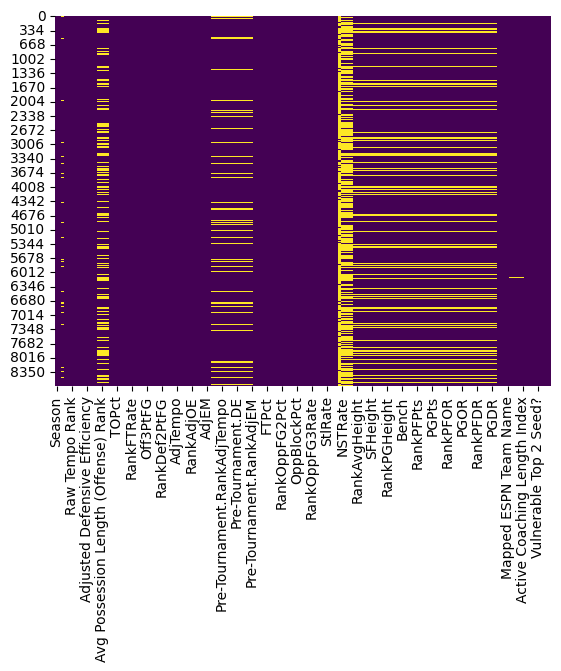

In [11]:
sns.heatmap(stats.isnull(), cbar=False, cmap='viridis')

In [12]:
missing_pct = stats.isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"Columns with any missingness ({len(missing_pct)} total):")
display(missing_pct.to_frame('missing_pct').style.format('{:.1%}'))

Columns with any missingness (77 total):


,missing_pct
DFP,87.8%
NSTRate,70.9%
RankNSTRate,70.9%
OppNSTRate,70.9%
RankOppNSTRate,70.9%
Avg Possession Length (Offense),30.7%
Avg Possession Length (Defense) Rank,30.7%
Avg Possession Length (Defense),30.7%
Avg Possession Length (Offense) Rank,30.7%
RankSGPts,18.9%


In [13]:
# impute marchmadnessall stats

LOW_MISSING_COLS = [
    'Adjusted Temo', 'Raw Tempo',
    'Adjusted Offensive Efficiency', 'Adjusted Defensive Efficiency', 'AdjEM',
    'Avg Possession Length (Offense)', 'Avg Possession Length (Defense)',
    'Off2PtFG', 'Off3PtFG', 'Def2PtFG', 'Def3PtFG',
    'FG3Rate', 'OppFG3Rate', 'ARate', 'OppARate', 'StlRate', 'OppStlRate',
    'BlockPct', 'OppBlockPct', 'DFP', 'NSTRate', 'OppNSTRate', 'Net Rating',
    'Pre-Tournament.Tempo', 'Pre-Tournament.AdjTempo',
    'Pre-Tournament.OE', 'Pre-Tournament.AdjOE',
    'Pre-Tournament.DE', 'Pre-Tournament.AdjDE',
    'Pre-Tournament.AdjEM',

]

MOST_MISSING_COLS = [
    'AvgHeight', 'CenterHeight', 'PFHeight', 'SFHeight', 'SGHeight', 'PGHeight', 'EffectiveHeight',
    'Experience', 'Bench',
    'CenterPts', 'PFPts', 'SFPts', 'SGPts', 'PGPts',
    'CenterOR', 'PFOR', 'SFOR', 'SGOR', 'PGOR',
    'CenterDR', 'PFDR', 'SFDR', 'SGDR', 'PGDR',
    'Top 12 in AP Top 25 During Week 6?',
    'Vulnerable Top 2 Seed?',
]

YES_NO_COLS = [
    'Top 12 in AP Top 25 During Week 6?',
    'Vulnerable Top 2 Seed?',
]

for col in LOW_MISSING_COLS:
    if col in stats.columns:
        stats[col] = stats[col].fillna(stats[col].median())

for col in MOST_MISSING_COLS:
    if col in stats.columns:
        if col in YES_NO_COLS:
            stats[col] = stats[col].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'YES': 1, 'NO': 0, True: 1, False: 0})
        flag_col = col.replace(' ', '_').replace('(', '').replace(')', '').replace('?', '').strip('_') + '_was_missing'
        stats[flag_col] = stats[col].isnull().astype(int)
        stats[col] = stats.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))
        # if entire season is missing, fall back to global median
        stats[col] = stats[col].fillna(stats[col].median())

# lots of data leakage :(
DROP_COLS = [
    'Tournament Winner?', 'Tournament Championship?', 'Final Four?',
    'Post-Season Tournament', 'Post-Season Tournament Sorting Index',
    'Active Coaching Length', 'Active Coaching Length Index',
]
stats.drop(columns=[c for c in DROP_COLS if c in stats.columns], inplace=True)

check_cols = [c for c in LOW_MISSING_COLS + MOST_MISSING_COLS if c in stats.columns]
remaining = stats[check_cols].isnull().sum()
print("Remaining nulls after imputation:")
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all clean")

Remaining nulls after imputation:
None — all clean


/var/folders/3z/jyhjhbks7yxgzl36tjc4g15h0000gn/T/ipykernel_66981/1423372348.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats[flag_col] = stats[col].isnull().astype(int)
/var/folders/3z/jyhjhbks7yxgzl36tjc4g15h0000gn/T/ipykernel_66981/1423372348.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats[flag_col] = stats[col].isnull().astype(int)
/var/folders/3z/jyhjhbks7yxgzl36tjc4g15h0000gn/T/ipykernel_66981/1423372348.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

## EDA

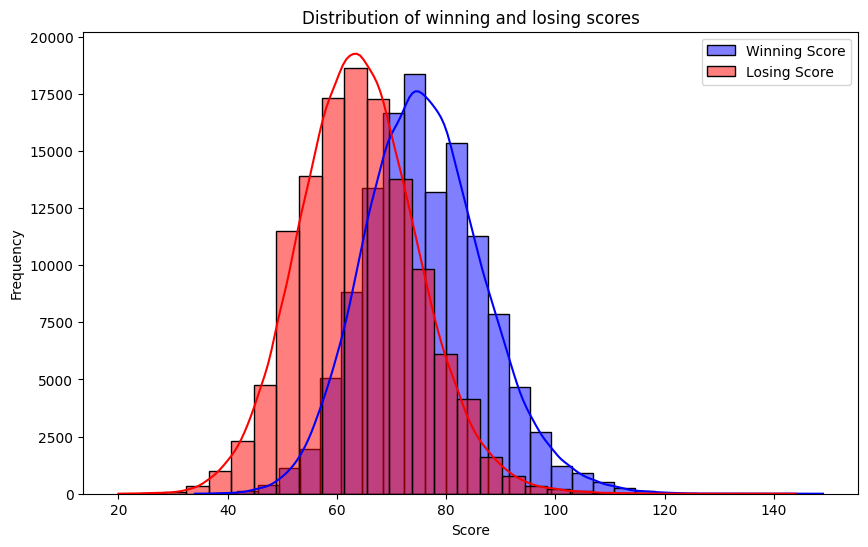

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(regular['WScore'], bins=30, kde=True, label='Winning Score', color='blue')
sns.histplot(regular['LScore'], bins=30, kde=True, label='Losing Score', color='red')
plt.title('Distribution of winning and losing scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

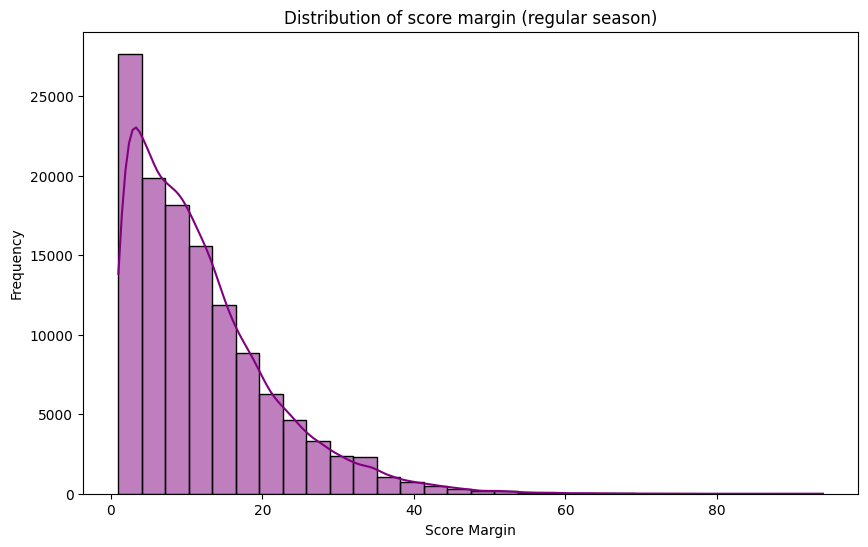

In [15]:
plt.figure(figsize=(10, 6))
score_diff = regular['WScore'] - regular['LScore']
sns.histplot(score_diff, bins=30, kde=True, color='purple')
plt.title('Distribution of score margin (regular season)')
plt.xlabel('Score Margin')
plt.ylabel('Frequency')
plt.show()

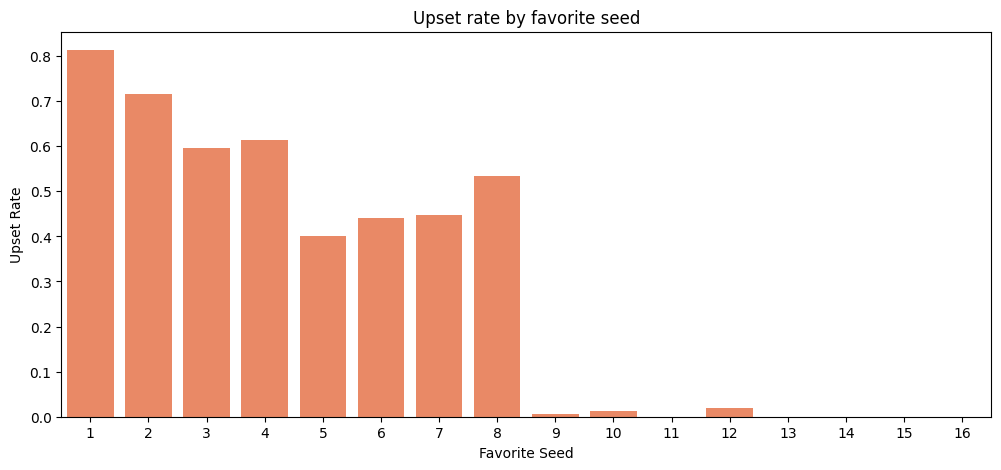

In [16]:
# seed vs upset rate
tourney_compact['WSeed'] = tourney_compact.apply(
    lambda r: seeds[(seeds['Season'] == r['Season']) & (seeds['TeamID'] == r['WTeamID'])]['Seed'].values[0][1:3]
    if len(seeds[(seeds['Season'] == r['Season']) & (seeds['TeamID'] == r['WTeamID'])]) > 0 else None, axis=1
)
tourney_compact['LSeed'] = tourney_compact.apply(
    lambda r: seeds[(seeds['Season'] == r['Season']) & (seeds['TeamID'] == r['LTeamID'])]['Seed'].values[0][1:3]
    if len(seeds[(seeds['Season'] == r['Season']) & (seeds['TeamID'] == r['LTeamID'])]) > 0 else None, axis=1
)
tourney_compact.dropna(subset=['WSeed', 'LSeed'], inplace=True)
tourney_compact['WSeed'] = tourney_compact['WSeed'].astype(int)
tourney_compact['LSeed'] = tourney_compact['LSeed'].astype(int)
tourney_compact['Upset'] = (tourney_compact['WSeed'] > tourney_compact['LSeed']).astype(int)
upset_rate = tourney_compact.groupby('LSeed')['Upset'].mean().reset_index()
upset_rate.columns = ['FavoriteSeed', 'UpsetRate']

plt.figure(figsize=(12, 5))
sns.barplot(data=upset_rate, x='FavoriteSeed', y='UpsetRate', color='coral')
plt.title('Upset rate by favorite seed')
plt.xlabel('Favorite Seed')
plt.ylabel('Upset Rate')
plt.show()

## Data Mapping

In [17]:
# map to team ID via mapped espn team name -- mteams.csv teamname
name_to_id = dict(zip(teams['TeamName'].str.strip().str.lower(),
                      teams['TeamID']))

stats['ESPN_Name'] = stats['Mapped ESPN Team Name'].str.strip()

espn_to_id = dict(zip(stats['ESPN_Name'], stats.apply(
    lambda r: teams[teams['TeamName'].str.strip() == r['ESPN_Name']]['TeamID'].values[0]
    if len(teams[teams['TeamName'].str.strip() == r['ESPN_Name']]) > 0 else None, axis=1
)))

team_dict = dict(zip(teams['TeamID'], teams['TeamName']))

print(f"stats shape: {stats.shape}")
print(f"Unique ESPN names in stats: {stats['ESPN_Name'].nunique()}")
display(stats[['Season', 'ESPN_Name', 'Adjusted Offensive Efficiency', 'AdjEM']].head(10))


/var/folders/3z/jyhjhbks7yxgzl36tjc4g15h0000gn/T/ipykernel_66981/1747666366.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats['ESPN_Name'] = stats['Mapped ESPN Team Name'].str.strip()


stats shape: (8680, 185)
Unique ESPN names in stats: 372


,Season,ESPN_Name,Adjusted Offensive Efficiency,AdjEM
0,2025,Duke,130.1,39.2864
1,2026,Duke,128.0,38.9156
2,2026,Arizona,127.7,37.6450
3,2026,Michigan,126.6,38.3549
4,2015,Kentucky,121.3,36.9118
5,2025,Houston,123.4,36.5890
6,2021,Gonzaga,126.4,36.4833
7,2024,UConn,127.5,36.4262
8,2025,Florida,128.2,36.4571
9,2008,Kansas,120.9,35.2083


# Feature Extraction and Creation

In [18]:
# elo!
# build game-by-game elo ratings across all regular seasons

K_FACTOR = 20
DEFAULT_ELO = 1500
SEASON_REGRESS = 0.4  # how much to regress to mean between seasons

def expected_score(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def update_elo(elo_a, elo_b, result_a):
    exp_a = expected_score(elo_a, elo_b)
    new_a = elo_a + K_FACTOR * (result_a - exp_a)
    new_b = elo_b + K_FACTOR * ((1 - result_a) - (1 - exp_a))
    return new_a, new_b

elo_ratings = {}  # {(season, team_id): elo}

regular_sorted = regular.sort_values(['Season', 'DayNum'])

for _, row in regular_sorted.iterrows():
    season = row['Season']
    w = row['WTeamID']
    l = row['LTeamID']

    elo_w = elo_ratings.get((season, w), DEFAULT_ELO)
    elo_l = elo_ratings.get((season, l), DEFAULT_ELO)

    # carry over and regress from prior season if first game
    if (season, w) not in elo_ratings:
        prior = elo_ratings.get((season - 1, w), DEFAULT_ELO)
        elo_w = prior * (1 - SEASON_REGRESS) + DEFAULT_ELO * SEASON_REGRESS
    if (season, l) not in elo_ratings:
        prior = elo_ratings.get((season - 1, l), DEFAULT_ELO)
        elo_l = prior * (1 - SEASON_REGRESS) + DEFAULT_ELO * SEASON_REGRESS

    new_w, new_l = update_elo(elo_w, elo_l, 1)
    elo_ratings[(season, w)] = new_w
    elo_ratings[(season, l)] = new_l

elo_df = pd.DataFrame([
    {'Season': s, 'TeamID': t, 'Elo': e}
    for (s, t), e in elo_ratings.items()
])
elo_df.head()

,Season,TeamID,Elo
0,2003,1104,1542.270147
1,2003,1328,1652.605175
2,2003,1272,1630.639219
3,2003,1393,1648.419643
4,2003,1266,1641.725417


In [19]:
# team season stats
# poss ≈ fga - or + tov + 0.44*fta

def compute_team_season_stats(df):
    rows = []
    for prefix, opp_prefix, outcome in [('W', 'L', 1), ('L', 'W', 0)]:
        tmp = df[['Season', f'{prefix}TeamID', f'{prefix}Score', f'{opp_prefix}Score',
                  f'{prefix}FGM', f'{prefix}FGA', f'{prefix}FGM3', f'{prefix}FGA3',
                  f'{prefix}FTM', f'{prefix}FTA', f'{prefix}OR', f'{prefix}DR',
                  f'{prefix}Ast', f'{prefix}TO', f'{prefix}Stl', f'{prefix}Blk', f'{prefix}PF',
                  f'{opp_prefix}FGA', f'{opp_prefix}OR', f'{opp_prefix}TO', f'{opp_prefix}FTA'
                  ]].copy()
        tmp.columns = ['Season', 'TeamID', 'Pts', 'OppPts',
                       'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR',
                       'Ast', 'TO', 'Stl', 'Blk', 'PF',
                       'OppFGA', 'OppOR', 'OppTO', 'OppFTA']
        tmp['Win'] = outcome
        rows.append(tmp)
    all_games = pd.concat(rows, ignore_index=True)

    all_games['Poss'] = all_games['FGA'] - all_games['OR'] + all_games['TO'] + 0.44 * all_games['FTA']
    all_games['OppPoss'] = all_games['OppFGA'] - all_games['OppOR'] + all_games['OppTO'] + 0.44 * all_games['OppFTA']
    all_games['ORtg'] = 100 * all_games['Pts'] / all_games['Poss'].replace(0, np.nan)
    all_games['DRtg'] = 100 * all_games['OppPts'] / all_games['OppPoss'].replace(0, np.nan)
    all_games['NetRtg'] = all_games['ORtg'] - all_games['DRtg']
    all_games['eFGPct'] = (all_games['FGM'] + 0.5 * all_games['FGM3']) / all_games['FGA'].replace(0, np.nan)
    all_games['TOPct'] = all_games['TO'] / all_games['Poss'].replace(0, np.nan)
    all_games['ORPct'] = all_games['OR'] / (all_games['OR'] + all_games['DR']).replace(0, np.nan)
    all_games['FTRate'] = all_games['FTA'] / all_games['FGA'].replace(0, np.nan)

    agg = all_games.groupby(['Season', 'TeamID']).agg(
        Avg_Pts=('Pts', 'mean'),
        Avg_OppPts=('OppPts', 'mean'),
        Games_Won=('Win', 'sum'),
        Total_Games=('Win', 'count'),
        ORtg=('ORtg', 'mean'),
        DRtg=('DRtg', 'mean'),
        NetRtg=('NetRtg', 'mean'),
        eFGPct=('eFGPct', 'mean'),
        TOPct=('TOPct', 'mean'),
        ORPct=('ORPct', 'mean'),
        FTRate=('FTRate', 'mean'),
        Avg_Ast=('Ast', 'mean'),
        Avg_TO=('TO', 'mean'),
        Avg_Stl=('Stl', 'mean'),
        Avg_Blk=('Blk', 'mean'),
    ).reset_index()

    agg['Win_Ratio'] = agg['Games_Won'] / agg['Total_Games']
    agg['Score_Margin'] = agg['Avg_Pts'] - agg['Avg_OppPts']
    return agg

In [20]:
team_stats = compute_team_season_stats(regular)
team_stats.head()

,Season,TeamID,Avg_Pts,Avg_OppPts,Games_Won,Total_Games,ORtg,DRtg,NetRtg,eFGPct,TOPct,ORPct,FTRate,Avg_Ast,Avg_TO,Avg_Stl,Avg_Blk,Win_Ratio,Score_Margin
0,2003,1102,57.250000,57.000000,12,28,104.902619,105.142005,-0.239386,0.584407,0.207292,0.197418,0.446693,13.000000,11.428571,5.964286,1.785714,0.428571,0.250000
1,2003,1103,78.777778,78.148148,13,27,111.985073,111.829472,0.155601,0.536564,0.181540,0.331088,0.465135,15.222222,12.629630,7.259259,2.333333,0.481481,0.629630
2,2003,1104,69.285714,65.000000,17,28,104.527648,98.975644,5.552004,0.475785,0.201266,0.361884,0.372350,12.107143,13.285714,6.607143,3.785714,0.607143,4.285714
3,2003,1105,71.769231,76.653846,7,26,93.942187,102.129410,-8.187222,0.457983,0.243300,0.366709,0.359501,14.538462,18.653846,9.307692,2.076923,0.269231,-4.884615
4,2003,1106,63.607143,63.750000,13,28,94.469094,95.562829,-1.093736,0.481697,0.253060,0.334892,0.307563,11.678571,17.035714,8.357143,3.142857,0.464286,-0.142857


In [21]:
# last N games form
N_RECENT = 15

def compute_recent_form(df, n=N_RECENT):
    rows = []
    for prefix, opp_prefix, outcome in [('W', 'L', 1), ('L', 'W', 0)]:
        tmp = df[['Season', 'DayNum', f'{prefix}TeamID', f'{prefix}Score', f'{opp_prefix}Score']].copy()
        tmp.columns = ['Season', 'DayNum', 'TeamID', 'Pts', 'OppPts']
        tmp['Win'] = outcome
        rows.append(tmp)
    all_games = pd.concat(rows).sort_values(['Season', 'TeamID', 'DayNum'])

    results = []
    for (season, team), grp in all_games.groupby(['Season', 'TeamID']):
        last_n = grp.tail(n)
        weights = np.arange(1, len(last_n) + 1)
        weighted_win = np.average(last_n['Win'], weights=weights)
        weighted_margin = np.average(last_n['Pts'] - last_n['OppPts'], weights=weights)
        results.append({'Season': season, 'TeamID': team,
                        'RecentWinPct': weighted_win, 'RecentMargin': weighted_margin})
    return pd.DataFrame(results)

recent_form = compute_recent_form(regular)
recent_form.head()

,Season,TeamID,RecentWinPct,RecentMargin
0,2003,1102,0.216667,-6.041667
1,2003,1103,0.508333,0.891667
2,2003,1104,0.408333,1.016667
3,2003,1105,0.233333,-0.833333
4,2003,1106,0.383333,-0.566667


In [22]:
# sos

def compute_sos(df, win_ratio_df):
    rows = []
    for prefix, opp_prefix in [('W', 'L'), ('L', 'W')]:
        tmp = df[['Season', f'{prefix}TeamID', f'{opp_prefix}TeamID']].copy()
        tmp.columns = ['Season', 'TeamID', 'OppID']
        rows.append(tmp)
    all_games = pd.concat(rows)
    merged = all_games.merge(win_ratio_df[['Season', 'TeamID', 'Win_Ratio']],
                             left_on=['Season', 'OppID'], right_on=['Season', 'TeamID'], how='left')
    sos = merged.groupby(['Season', 'TeamID_x'])['Win_Ratio'].mean().reset_index()
    sos.columns = ['Season', 'TeamID', 'SOS']
    return sos

sos = compute_sos(regular, team_stats)
sos.head()

,Season,TeamID,SOS
0,2003,1102,0.530644
1,2003,1103,0.489779
2,2003,1104,0.572492
3,2003,1105,0.415228
4,2003,1106,0.458062


In [23]:
# massey rankings from last ranking

massey_final = massey[massey['RankingDayNum'] == 133].copy()

massey_agg = massey_final.groupby(['Season', 'TeamID']).agg(
    MasseyMean=('OrdinalRank', 'mean'),
    MasseyMin=('OrdinalRank', 'min'),
    MasseyStd=('OrdinalRank', 'std'),
    MasseyMedian=('OrdinalRank', 'median'),
    NumSystems=('SystemName', 'count')
).reset_index()

for sys_name in ['POM', 'SAG', 'RPI', 'ESPN']:
    sys_df = massey_final[massey_final['SystemName'] == sys_name][['Season', 'TeamID', 'OrdinalRank']].copy()
    sys_df.rename(columns={'OrdinalRank': f'Rank_{sys_name}'}, inplace=True)
    massey_agg = massey_agg.merge(sys_df, on=['Season', 'TeamID'], how='left')

massey_agg.head()

,Season,TeamID,MasseyMean,MasseyMin,MasseyStd,MasseyMedian,NumSystems,Rank_POM,Rank_SAG,Rank_RPI,Rank_ESPN
0,2003,1102,156.03125,97,17.102130,156.0,32,160.0,149.0,158.0,NaN
1,2003,1103,168.00000,128,12.559536,170.5,32,163.0,172.0,182.0,NaN
2,2003,1104,38.03125,26,6.794136,37.0,32,33.0,37.0,38.0,NaN
3,2003,1105,308.96875,289,5.877702,310.0,32,307.0,312.0,313.0,NaN
4,2003,1106,262.68750,198,21.178866,265.5,32,263.0,268.0,248.0,NaN


In [24]:
def parse_seed(seed_str):
    try:
        return int(str(seed_str)[1:3])
    except:
        return 16

seeds['SeedNum'] = seeds['Seed'].apply(parse_seed)
seeds['Region'] = seeds['Seed'].str[0]
seeds.head()

,Season,Seed,TeamID,SeedNum,Region
0,1985,W01,1207,1,W
1,1985,W02,1210,2,W
2,1985,W03,1228,3,W
3,1985,W04,1260,4,W
4,1985,W05,1374,5,W


In [25]:
# coach time ki pass

coach_tenure = coaches.groupby(['Season', 'TeamID', 'CoachName']).agg(
    LastDay=('LastDayNum', 'max')
).reset_index()
# keep the coach active at end of season (LastDayNum == 154 or max)
coach_tenure = coach_tenure.sort_values(['TeamID', 'CoachName', 'Season'])
coach_tenure['CoachSeasons'] = coach_tenure.groupby(['TeamID', 'CoachName']).cumcount() + 1
# keep only end-of-season entry per team
coach_final = coach_tenure.groupby(['Season', 'TeamID']).apply(
    lambda g: g.loc[g['LastDay'].idxmax()]
).reset_index(drop=True)[['Season', 'TeamID', 'CoachName', 'CoachSeasons']]
coach_final.head()

/var/folders/3z/jyhjhbks7yxgzl36tjc4g15h0000gn/T/ipykernel_66981/1698980892.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coach_final = coach_tenure.groupby(['Season', 'TeamID']).apply(


,Season,TeamID,CoachName,CoachSeasons
0,1985,1102,reggie_minton,1
1,1985,1103,bob_huggins,1
2,1985,1104,wimp_sanderson,1
3,1985,1106,james_oliver,1
4,1985,1108,davey_whitney,1


In [26]:
# conference tournament

conf_wins = []
for prefix, outcome in [('W', 1), ('L', 0)]:
    tmp = conf_tourney[['Season', 'ConfAbbrev', f'{prefix}TeamID']].copy()
    tmp.columns = ['Season', 'ConfAbbrev', 'TeamID']
    tmp['ConfWin'] = outcome
    conf_wins.append(tmp)
conf_all = pd.concat(conf_wins)
conf_perf = conf_all.groupby(['Season', 'TeamID']).agg(
    ConfTourneyWins=('ConfWin', 'sum'),
    ConfTourneyGames=('ConfWin', 'count')
).reset_index()
conf_perf['ConfChamp'] = (conf_perf['ConfTourneyWins'] >= conf_perf['ConfTourneyGames']).astype(int)
conf_perf.head()

,Season,TeamID,ConfTourneyWins,ConfTourneyGames,ConfChamp
0,2001,1102,0,1,0
1,2001,1103,0,1,0
2,2001,1104,1,2,0
3,2001,1106,3,3,1
4,2001,1108,2,3,0


In [27]:
# team feats df

team_features = team_stats.copy()
team_features = team_features.merge(elo_df, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(recent_form, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(sos, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(massey_agg, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(
    seeds[['Season', 'TeamID', 'SeedNum', 'Region']], on=['Season', 'TeamID'], how='left'
)
team_features = team_features.merge(coach_final[['Season', 'TeamID', 'CoachSeasons']], on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(conf_perf, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(conferences[['Season', 'TeamID', 'ConfAbbrev']], on=['Season', 'TeamID'], how='left')

In [28]:
id_to_name = dict(zip(teams['TeamID'], teams['TeamName']))
name_to_espn = dict(zip(stats['Mapped ESPN Team Name'], stats['ESPN_Name']))
team_features['ESPN_Name'] = team_features['TeamID'].map(id_to_name).map(name_to_espn)

matched = team_features['ESPN_Name'].notna().sum()
print(f"ESPN_Name attached: {matched}/{len(team_features)} ({matched/len(team_features):.1%})")

ESPN_Name attached: 5027/8346 (60.2%)


In [29]:
# stats columns to include in features
STATS_VALUE_COLS = [
    'Adjusted_Temo', 'Raw_Tempo',
    'Adjusted_Offensive_Efficiency', 'Adjusted_Defensive_Efficiency', 'AdjEM',
    'Avg_Possession_Length_Offense', 'Avg_Possession_Length_Defense',
    'Off2PtFG', 'Off3PtFG', 'Def2PtFG', 'Def3PtFG',
    'FG3Rate', 'OppFG3Rate', 'ARate', 'OppARate', 'StlRate', 'OppStlRate',
    'BlockPct', 'OppBlockPct', 'DFP', 'NSTRate', 'OppNSTRate', 'Net_Rating',
    'Pre-Tournament_Tempo', 'Pre-Tournament_AdjTempo',
    'Pre-Tournament_OE', 'Pre-Tournament_AdjOE',
    'Pre-Tournament_DE', 'Pre-Tournament_AdjDE',
    'Pre-Tournament_AdjEM',
    'AvgHeight', 'CenterHeight', 'PFHeight', 'SFHeight', 'SGHeight', 'PGHeight', 'EffectiveHeight',
    'Experience', 'Bench',
    'CenterPts', 'PFPts', 'SFPts', 'SGPts', 'PGPts',
    'CenterOR', 'PFOR', 'SFOR', 'SGOR', 'PGOR',
    'CenterDR', 'PFDR', 'SFDR', 'SGDR', 'PGDR',
    'Top_12_in_AP_Top_25_During_Week_6',
    'Vulnerable_Top_2_Seed',
]

In [30]:
# rename stats columns to be join-friendly (already done during imputation)
stats_renamed = stats.copy()
stats_renamed.columns = [
    c.replace(' ', '_').replace('(', '').replace(')', '').replace('?', '').replace('.', '_').strip('_')
    for c in stats_renamed.columns
]

# include missingness flag columns
flag_cols = [c for c in stats_renamed.columns if c.endswith('_was_missing')]
stats_cols_to_merge = [c for c in STATS_VALUE_COLS if c in stats_renamed.columns] + flag_cols
stats_merge = stats_renamed[['Season', 'ESPN_Name'] + stats_cols_to_merge].copy()

team_features = team_features.merge(stats_merge, on=['Season', 'ESPN_Name'], how='left')

# fill missings
for col in ['MasseyMean', 'MasseyMin', 'MasseyStd', 'MasseyMedian', 'Rank_POM', 'Rank_SAG', 'Rank_RPI', 'Rank_ESPN']:
    team_features[col] = team_features[col].fillna(team_features[col].median())
team_features['CoachSeasons'] = team_features['CoachSeasons'].fillna(1)
team_features['ConfTourneyWins'] = team_features['ConfTourneyWins'].fillna(0)
team_features['ConfChamp'] = team_features['ConfChamp'].fillna(0)

for col in stats_cols_to_merge:
    if col in team_features.columns:
        if col.endswith('_was_missing'):
            team_features[col] = team_features[col].fillna(1)
        else:
            team_features[col] = team_features[col].fillna(team_features[col].median())

print(team_features.shape)
display(team_features.head())

(8346, 122)


,Season,TeamID,Avg_Pts,Avg_OppPts,Games_Won,Total_Games,ORtg,DRtg,NetRtg,eFGPct,...,SFOR_was_missing,SGOR_was_missing,PGOR_was_missing,CenterDR_was_missing,PFDR_was_missing,SFDR_was_missing,SGDR_was_missing,PGDR_was_missing,Top_12_in_AP_Top_25_During_Week_6_was_missing,Vulnerable_Top_2_Seed_was_missing
0,2003,1102,57.250000,57.000000,12,28,104.902619,105.142005,-0.239386,0.584407,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
1,2003,1103,78.777778,78.148148,13,27,111.985073,111.829472,0.155601,0.536564,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,2003,1104,69.285714,65.000000,17,28,104.527648,98.975644,5.552004,0.475785,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
3,2003,1105,71.769231,76.653846,7,26,93.942187,102.129410,-8.187222,0.457983,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
4,2003,1106,63.607143,63.750000,13,28,94.469094,95.562829,-1.093736,0.481697,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [31]:
team_features.isnull().sum()[team_features.isnull().sum() > 0]

NumSystems           719
Rank_ESPN           8346
SeedNum             6874
Region              6874
ConfTourneyGames    1307
ESPN_Name           3319
dtype: int64

In [32]:
# Vulnerability score — captures upset-prone favorites
def compute_vulnerability(row):
    vuln = 0.0
    if pd.notna(row.get('TOPct')):
        vuln += row['TOPct'] * 2.0
    if pd.notna(row.get('RecentWinPct')) and pd.notna(row.get('Win_Ratio')):
        form_drop = row['Win_Ratio'] - row['RecentWinPct']
        vuln += max(form_drop, 0) * 1.5
    if pd.notna(row.get('Experience')):
        vuln += max(0, (2.0 - row['Experience'])) * 0.5
    return vuln

team_features['VulnerabilityScore'] = team_features.apply(compute_vulnerability, axis=1)
print("VulnerabilityScore added:", team_features['VulnerabilityScore'].describe())

VulnerabilityScore added: count    8346.000000
mean        0.627627
std         0.183769
min         0.225291
25%         0.508420
50%         0.592325
75%         0.721935
max         1.583627
Name: VulnerabilityScore, dtype: float64


# Compile Dataset

In [33]:
# KEY FEATURES from FULL team_features
FEATURE_COLS = [
    # ref: kaggle
    'Elo', 'Win_Ratio', 'Score_Margin', 'NetRtg',
    'eFGPct', 'TOPct', 'ORPct', 'FTRate', 'Avg_Pts', 'Avg_OppPts',
    'Avg_Ast', 'Avg_TO', 'Avg_Stl', 'Avg_Blk',
    'RecentWinPct', 'RecentMargin', 'SOS', 'SeedNum',
    # ref: massey
    'MasseyMean', 'MasseyMin', 'MasseyStd', 'MasseyMedian',
    'Rank_POM', 'Rank_SAG', 'Rank_RPI', 'Rank_ESPN',
    # ref: kaggle ++
    'CoachSeasons', 'ConfTourneyWins', 'ConfChamp',
    # ref: marchmadnessall
    'Adjusted_Temo', 'AdjEM',
    'Avg_Possession_Length_Offense', 'Avg_Possession_Length_Defense',
    'Off2PtFG', 'Off3PtFG', 'Def2PtFG', 'Def3PtFG',
    'FG3Rate', 'OppFG3Rate', 'ARate', 'OppARate', 'StlRate', 'OppStlRate',
    'BlockPct', 'OppBlockPct', 'DFP', 'Net_Rating',
    'Pre-Tournament_AdjOE', 'Pre-Tournament_AdjDE',
    'Pre-Tournament_AdjEM',
    # ref: marchmadnessall imputed
    'AvgHeight', 'EffectiveHeight', 'Experience', 'Bench',
    # 'CenterHeight', 'PFHeight', 'SFHeight', 'SGHeight', 'PGHeight',
    # 'CenterPts', 'PFPts', 'SFPts', 'SGPts', 'PGPts',
    # 'CenterOR', 'PFOR', 'SFOR', 'SGOR', 'PGOR',
    # 'CenterDR', 'PFDR', 'SFDR', 'SGDR', 'PGDR',
    'Top_12_in_AP_Top_25_During_Week_6',
    'Vulnerable_Top_2_Seed',
    # upset features
    'VulnerabilityScore',

]

FEATURE_COLS = [c for c in FEATURE_COLS if c in team_features.columns]
print(f"Using {len(FEATURE_COLS)} features")

Using 57 features


In [34]:
def get_round(daynum):
    if daynum <= 135:
        return 0
    elif daynum <= 137:
        return 1
    elif daynum <= 139:
        return 2
    elif daynum <= 144:
        return 3
    elif daynum <= 146:
        return 4
    elif daynum <= 152:
        return 5
    else:
        return 6

In [35]:
matchups = []

for _, game in tourney.iterrows():
    season = game['Season']
    w_team = game['WTeamID']
    l_team = game['LTeamID']
    round_num = get_round(game['DayNum'])

    w_name = team_dict.get(w_team, '')
    l_name = team_dict.get(l_team, '')

    w_feats = team_features[(team_features['Season'] == season) & (team_features['ESPN_Name'] == w_name)]
    l_feats = team_features[(team_features['Season'] == season) & (team_features['ESPN_Name'] == l_name)]

    if len(w_feats) == 0 or len(l_feats) == 0:
        continue

    w_seed = int(seeds[(seeds['Season'] == season) & (seeds['TeamID'] == w_team)]['SeedNum'].values[0]) \
        if len(seeds[(seeds['Season'] == season) & (seeds['TeamID'] == w_team)]) > 0 else 16
    l_seed = int(seeds[(seeds['Season'] == season) & (seeds['TeamID'] == l_team)]['SeedNum'].values[0]) \
        if len(seeds[(seeds['Season'] == season) & (seeds['TeamID'] == l_team)]) > 0 else 16

    features = {'Season': season, 'Round': round_num, 'SeedDiff': l_seed - w_seed}

    # raw seed values — model sees absolute quality, not just difference
    features['Seed_A']         = w_seed
    features['Seed_B']         = l_seed
    features['SeedProduct']    = w_seed * l_seed   # high = both mid-seeds = closer game
    features['HighSeedGame']   = int(min(w_seed, l_seed) >= 4)  # no 1/2/3 seeds

    # known upset-prone matchups historically
    seed_pair = tuple(sorted([w_seed, l_seed]))
    features['IsFiveTwelve']   = int(seed_pair == (5, 12))
    features['IsElevenSix']    = int(seed_pair == (6, 11))
    features['IsTenSeven']     = int(seed_pair == (7, 10))
    features['IsThirteenFour'] = int(seed_pair == (4, 13))

    # vulnerability of the favorite in this matchup
    fav_feats = w_feats if w_seed <= l_seed else l_feats
    features['FavoriteVulnerability'] = float(fav_feats['VulnerabilityScore'].values[0]) \
        if 'VulnerabilityScore' in fav_feats.columns else 0.0

    for col in FEATURE_COLS:
        if col in w_feats.columns and col in l_feats.columns:
            features[f'{col}_diff'] = float(w_feats[col].values[0]) - float(l_feats[col].values[0])
    features['Team'] = w_name
    features['Opponent'] = l_name
    features['result'] = 1
    matchups.append(features)

    features_rev = features.copy()
    for col in features.keys():
        if col.endswith('_diff'):
            features_rev[col] = -features[col]
    # flip seed perspective for reversed matchup
    features_rev['SeedDiff']  = -features['SeedDiff']
    features_rev['Seed_A']    = l_seed
    features_rev['Seed_B']    = w_seed
    # SeedProduct, HighSeedGame, upset flags stay the same (symmetric)
    # FavoriteVulnerability stays the same (same favorite either way)
    features_rev['Team']      = l_name
    features_rev['Opponent']  = w_name
    features_rev['result']    = 0
    matchups.append(features_rev)

matchup_data = pd.DataFrame(matchups)
print(matchup_data.shape)
display(matchup_data.head())

(1654, 72)


,Season,Round,SeedDiff,Seed_A,Seed_B,SeedProduct,HighSeedGame,IsFiveTwelve,IsElevenSix,IsTenSeven,...,AvgHeight_diff,EffectiveHeight_diff,Experience_diff,Bench_diff,Top_12_in_AP_Top_25_During_Week_6_diff,Vulnerable_Top_2_Seed_diff,VulnerabilityScore_diff,Team,Opponent,result
0,2003,1,15,1,16,16,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.031268,Arizona,Vermont,1
1,2003,1,-15,16,1,16,0,0,0,0,...,-0.0,-0.0,-0.0,-0.0,-1.0,-1.0,-0.031268,Vermont,Arizona,0
2,2003,1,1,8,9,72,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.112557,California,NC State,1
3,2003,1,-1,9,8,72,1,0,0,0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.112557,NC State,California,0
4,2003,1,-1,9,8,72,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.211916,Gonzaga,Cincinnati,1


In [36]:
matchup_data

,Season,Round,SeedDiff,Seed_A,Seed_B,SeedProduct,HighSeedGame,IsFiveTwelve,IsElevenSix,IsTenSeven,...,AvgHeight_diff,EffectiveHeight_diff,Experience_diff,Bench_diff,Top_12_in_AP_Top_25_During_Week_6_diff,Vulnerable_Top_2_Seed_diff,VulnerabilityScore_diff,Team,Opponent,result
0,2003,1,15,1,16,16,0,0,0,0,...,0.00,0.00,0.00000,0.00,1.0,1.0,0.031268,Arizona,Vermont,1
1,2003,1,-15,16,1,16,0,0,0,0,...,-0.00,-0.00,-0.00000,-0.00,-1.0,-1.0,-0.031268,Vermont,Arizona,0
2,2003,1,1,8,9,72,1,0,0,0,...,0.00,0.00,0.00000,0.00,0.0,0.0,0.112557,California,NC State,1
3,2003,1,-1,9,8,72,1,0,0,0,...,-0.00,-0.00,-0.00000,-0.00,-0.0,-0.0,-0.112557,NC State,California,0
4,2003,1,-1,9,8,72,1,0,0,0,...,0.00,0.00,0.00000,0.00,0.0,0.0,-0.211916,Gonzaga,Cincinnati,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,2025,5,0,1,1,1,0,0,0,0,...,0.55,-0.87,0.36589,2.81,-0.0,-0.0,0.306010,Auburn,Florida,0
1650,2025,5,0,1,1,1,0,0,0,0,...,-2.97,-2.70,0.71017,-1.02,-1.0,0.0,-0.025111,Houston,Duke,1
1651,2025,5,0,1,1,1,0,0,0,0,...,2.97,2.70,-0.71017,1.02,1.0,-0.0,0.025111,Duke,Houston,0
1652,2025,6,0,1,1,1,0,0,0,0,...,1.15,2.36,-0.22496,-0.22,1.0,0.0,0.014661,Florida,Houston,1


In [37]:
matchup_data.isnull().sum()[matchup_data.isnull().sum() > 0]

Rank_ESPN_diff    1654
dtype: int64

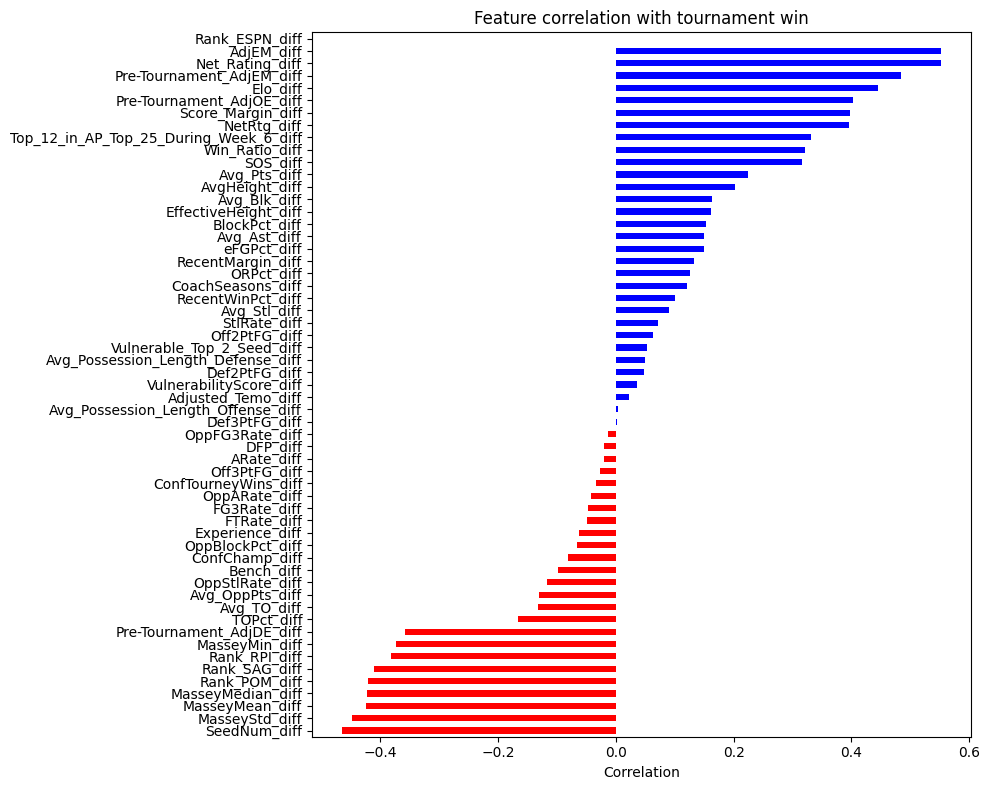

In [38]:
# corr heat map of features vs result
diff_cols = [c for c in matchup_data.columns if c.endswith('_diff')]
corr = matchup_data[diff_cols + ['result']].corr()['result'].drop('result').sort_values()

plt.figure(figsize=(10, 8))
corr.plot(kind='barh', color=['red' if v < 0 else 'blue' for v in corr])
plt.title('Feature correlation with tournament win')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# Train Test Split Data

In [39]:
# szn stratefied split - tuff or nah

TRAIN_SEASONS = list(range(2010, 2022))
VAL_SEASONS   = [2022, 2023]
TEST_SEASONS  = [2024, 2025]

feat_cols = [c for c in matchup_data.columns if c not in ['Season', 'result', 'Team', 'Opponent']]

train_df = matchup_data[matchup_data['Season'].isin(TRAIN_SEASONS)]
val_df   = matchup_data[matchup_data['Season'].isin(VAL_SEASONS)]
test_df  = matchup_data[matchup_data['Season'].isin(TEST_SEASONS)]

X_train, y_train = train_df[feat_cols], train_df['result']
X_val,   y_val   = val_df[feat_cols],   val_df['result']
X_test,  y_test  = test_df[feat_cols],  test_df['result']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (832, 68), Val: (124, 68), Test: (160, 68)


In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [41]:
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0)

In [42]:
# kfolds — only used for OOF stacking, not for training base models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_scaled, y_train)):
    print(f"Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}")

Fold 1: train=665, val=167
Fold 2: train=665, val=167
Fold 3: train=666, val=166
Fold 4: train=666, val=166
Fold 5: train=666, val=166


# Models

## XGB

In [43]:
# XGB — Optuna tuned, trained on full training set
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    m = xgb.XGBClassifier(**params, early_stopping_rounds=30)
    m.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
    return log_loss(y_val, m.predict_proba(X_val_scaled)[:, 1])

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
print("Best XGB params:", study_xgb.best_params)
print(f"Best XGB log loss: {study_xgb.best_value:.4f}")

xgb_model = xgb.XGBClassifier(
    **study_xgb.best_params,
    early_stopping_rounds=50,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)

xgb_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
print("XGB:")
print(f"Log Loss: {log_loss(y_val, xgb_val_proba):.4f}")
print(f"Brier: {brier_score_loss(y_val, xgb_val_proba):.4f}")
print(f"Acc: {accuracy_score(y_val, (xgb_val_proba>0.5).astype(int)):.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best XGB params: {'n_estimators': 760, 'max_depth': 5, 'learning_rate': 0.01435893700300223, 'subsample': 0.8780685029611865, 'colsample_bytree': 0.56680554908322, 'min_child_weight': 3, 'reg_alpha': 0.11113802301449667, 'reg_lambda': 0.6466858149274476}
Best XGB log loss: 0.4627
XGB:
Log Loss: 0.4627
Brier: 0.1446
Acc: 0.8145


## LGBM

In [44]:
# LGB — Optuna tuned, trained on full training set
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'num_leaves': trial.suggest_int('num_leaves', 8, 31),
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 40),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'objective': 'binary',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }
    m = lgb.LGBMClassifier(**params, callbacks=[lgb.early_stopping(30), lgb.log_evaluation(-1)])
    m.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])
    return log_loss(y_val, m.predict_proba(X_val_scaled)[:, 1])

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)
print("Best LGB params:", study_lgb.best_params)
print(f"Best LGB log loss: {study_lgb.best_value:.4f}")

lgb_model = lgb.LGBMClassifier(
    **study_lgb.best_params,
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)
lgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])

lgb_val_proba = lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_test_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
print("LGB:")
print(f"Log Loss: {log_loss(y_val, lgb_val_proba):.4f}")
print(f"Brier: {brier_score_loss(y_val, lgb_val_proba):.4f}")
print(f"Acc: {accuracy_score(y_val, (lgb_val_proba>0.5).astype(int)):.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best LGB params: {'n_estimators': 1596, 'max_depth': 5, 'num_leaves': 8, 'learning_rate': 0.0030112516965007715, 'subsample': 0.6086957144549894, 'colsample_bytree': 0.5568828084496241, 'min_child_samples': 33, 'reg_alpha': 0.013848187509726944, 'reg_lambda': 0.6601930187066637}
Best LGB log loss: 0.4648
LGB:
Log Loss: 0.4648
Brier: 0.1476
Acc: 0.7984


## CatBoost

In [45]:
# CatBoost
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 2000),
        'depth': trial.suggest_int('depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2.0),
        'border_count': trial.suggest_int('border_count', 64, 254),
        'random_seed': 42,
        'eval_metric': 'Logloss',
        'verbose': False,
    }
    m = CatBoostClassifier(**params, early_stopping_rounds=30)
    m.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), verbose=False)
    return log_loss(y_val, m.predict_proba(X_val_scaled)[:, 1])

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=100, show_progress_bar=True)
print("Best CAT params:", study_cat.best_params)
print(f"Best CAT log loss: {study_cat.best_value:.4f}")

cat_model = CatBoostClassifier(
    **study_cat.best_params,
    early_stopping_rounds=50,
    eval_metric='Logloss',
    random_seed=42,
    verbose=200,
)
cat_model.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val))

cat_val_proba = cat_model.predict_proba(X_val_scaled)[:, 1]
cat_test_proba = cat_model.predict_proba(X_test_scaled)[:, 1]
print("CatBoost:")
print(f"Log Loss: {log_loss(y_val, cat_val_proba):.4f}")
print(f"Brier: {brier_score_loss(y_val, cat_val_proba):.4f}")
print(f"Acc: {accuracy_score(y_val, (cat_val_proba>0.5).astype(int)):.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best CAT params: {'iterations': 410, 'depth': 3, 'learning_rate': 0.04203183496093694, 'l2_leaf_reg': 1.2724438592060248, 'bagging_temperature': 1.2223547737563643, 'random_strength': 0.5392829465628209, 'border_count': 115}
Best CAT log loss: 0.4866
0:	learn: 0.6781740	test: 0.6782321	best: 0.6782321 (0)	total: 940us	remaining: 385ms
200:	learn: 0.3021174	test: 0.4866848	best: 0.4866073 (193)	total: 122ms	remaining: 127ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4866072902
bestIteration = 193

Shrink model to first 194 iterations.
CatBoost:
Log Loss: 0.4866
Brier: 0.1584
Acc: 0.7903


## Log Reg

In [46]:
#logreg
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
print("LR:")
print(f"Log Loss: {log_loss(y_val, lr_val_proba):.4f}") 
print(f"Brier: {brier_score_loss(y_val, lr_val_proba):.4f}")
print(f"Acc: {accuracy_score(y_val, (lr_val_proba>0.5).astype(int)):.4f}")

LR:
Log Loss: 0.5185
Brier: 0.1750
Acc: 0.7258


## Neural Net

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# ── Label smoothing loss ───────────────────────────────────────────────────────
class LabelSmoothBCE(nn.Module):
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(logits, targets_smooth)


# ── Residual block for the team encoder ───────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))   # residual skip connection


# ── Main model ─────────────────────────────────────────────────────────────────
class WowzaNetV2(nn.Module):
    """
    Siamese encoder with richer interaction head.
    Input: concatenated [team_a_features | team_b_features]
    The same encoder weights are shared for both teams (symmetry preserved).
    """
    def __init__(self, input_dim, embed_dim=64, dropout=0.35):
        super().__init__()
        half = input_dim // 2

        # Project raw features → embedding space
        self.input_proj = nn.Sequential(
            nn.Linear(half, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Deep residual encoder — shared weights across both teams
        self.encoder = nn.Sequential(
            ResBlock(embed_dim, dropout=dropout),
            ResBlock(embed_dim, dropout=dropout),
            ResBlock(embed_dim, dropout=dropout),
        )

        # Interaction head takes: [diff, abs_diff, product, mean]
        # 4 * embed_dim input
        interaction_dim = 4 * embed_dim
        self.head = nn.Sequential(
            nn.Linear(interaction_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1),   # raw logit — no sigmoid here
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def encode(self, x):
        return self.encoder(self.input_proj(x))

    def forward(self, x):
        half = x.shape[1] // 2
        emb_a = self.encode(x[:, :half])
        emb_b = self.encode(x[:, half:])

        diff     = emb_a - emb_b              # directional signal
        abs_diff = torch.abs(diff)            # magnitude signal
        prod     = emb_a * emb_b             # interaction signal
        mean     = (emb_a + emb_b) / 2       # context signal

        combined = torch.cat([diff, abs_diff, prod, mean], dim=1)
        return self.head(combined).squeeze(1)  # raw logit

In [48]:
input_dim = X_train_scaled.shape[1]
if input_dim % 2 != 0:
    X_train_nn = np.hstack([X_train_scaled, np.zeros((X_train_scaled.shape[0], 1))])
    X_val_nn   = np.hstack([X_val_scaled,   np.zeros((X_val_scaled.shape[0],   1))])
    X_test_nn  = np.hstack([X_test_scaled,  np.zeros((X_test_scaled.shape[0],  1))])
    input_dim += 1
else:
    X_train_nn, X_val_nn, X_test_nn = X_train_scaled, X_val_scaled, X_test_scaled

In [49]:
# ── Data augmentation: flip team A/B for free 2x data ─────────────────────────
half_nn = X_train_nn.shape[1] // 2
X_train_flipped = np.hstack([X_train_nn[:, half_nn:], X_train_nn[:, :half_nn]])
y_train_flipped = 1 - y_train.values

X_train_aug = np.vstack([X_train_nn, X_train_flipped])
y_train_aug  = np.concatenate([y_train.values, y_train_flipped])

# ── Datasets ───────────────────────────────────────────────────────────────────
train_tensor = TensorDataset(
    torch.FloatTensor(X_train_aug),
    torch.FloatTensor(y_train_aug)
)
val_tensor = TensorDataset(
    torch.FloatTensor(X_val_nn.copy()),
    torch.FloatTensor(y_val.values)
)
train_loader = DataLoader(train_tensor, batch_size=32, shuffle=True)  # smaller batch = more updates
val_loader   = DataLoader(val_tensor,   batch_size=64)

# ── Model, optimizer, scheduler ───────────────────────────────────────────────
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nn_model = WowzaNetV2(input_dim, embed_dim=64, dropout=0.35).to(device)

optimizer = optim.AdamW(
    nn_model.parameters(),
    lr=3e-4,
    weight_decay=5e-3,    # stronger than Adam default
)
criterion = LabelSmoothBCE(smoothing=0.05)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=30, T_mult=2, eta_min=1e-5
)

# ── Training ───────────────────────────────────────────────────────────────────
EPOCHS    = 200
PATIENCE  = 25
best_val_loss = float('inf')
best_state    = None
no_improve    = 0

for epoch in range(EPOCHS):
    nn_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(nn_model.parameters(), max_norm=1.0)  # gradient clip
        optimizer.step()
    scheduler.step()

    # ── Validation ────────────────────────────────────────────────────────────
    nn_model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_losses.append(criterion(nn_model(xb), yb).item())
    val_loss = np.mean(val_losses)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in nn_model.state_dict().items()}
        no_improve    = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stop at epoch {epoch+1}, best val_loss: {best_val_loss:.4f}")
            break

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1} | val_loss: {val_loss:.4f} | best: {best_val_loss:.4f}")

# ── Inference: apply sigmoid to convert logits → probabilities ─────────────────
nn_model.load_state_dict(best_state)
nn_model.eval()
with torch.no_grad():
    nn_val_logits  = nn_model(torch.FloatTensor(X_val_nn.copy()).to(device))
    nn_val_proba   = torch.sigmoid(nn_val_logits).cpu().numpy()
    nn_test_logits = nn_model(torch.FloatTensor(X_test_nn.copy()).to(device))
    nn_test_proba  = torch.sigmoid(nn_test_logits).cpu().numpy()

print("WowzaNet v2:")
print(f"Log Loss : {log_loss(y_val, nn_val_proba):.4f}")
print(f"Brier    : {brier_score_loss(y_val, nn_val_proba):.4f}")
print(f"Acc      : {accuracy_score(y_val, (nn_val_proba > 0.5).astype(int)):.4f}")

Epoch 25 | val_loss: 0.5910 | best: 0.5716
Early stop at epoch 30, best val_loss: 0.5716
WowzaNet v2:
Log Loss : 0.5552
Brier    : 0.1829
Acc      : 0.7500


## Ensemble

In [50]:
# Ensemble — proper OOF stacking, no leakage
from sklearn.base import clone

def get_oof_predictions(model, X, y, cv, model_type='xgb'):
    oof = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_vl = X[train_idx], X[val_idx]
        y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]
        m = clone(model)

        if model_type == 'xgb':
            m.fit(X_tr, y_tr,
                  eval_set=[(X_vl, y_vl)],
                  verbose=False)
        elif model_type == 'lgb':
            m.fit(X_tr, y_tr,
                  eval_set=[(X_vl, y_vl)])
        elif model_type == 'cat':
            m.fit(X_tr, y_tr,
                  eval_set=(X_vl, y_vl),
                  verbose=False)

        oof[val_idx] = m.predict_proba(X_vl)[:, 1]
        print(f"  {model_type} fold {fold+1} done | fold log loss: {log_loss(y_vl, oof[val_idx]):.4f}")

    print(f"{model_type} OOF log loss: {log_loss(y, oof):.4f}")
    return oof

print("Generating OOF predictions (this takes a few minutes)...")
xgb_oof = get_oof_predictions(xgb_model, X_train_scaled, y_train, cv, model_type='xgb')
lgb_oof = get_oof_predictions(lgb_model, X_train_scaled, y_train, cv, model_type='lgb')
cat_oof = get_oof_predictions(cat_model, X_train_scaled, y_train, cv, model_type='cat')
print("OOF done.")

# Simple average — often the strongest baseline
avg_val  = (xgb_val_proba + lgb_val_proba + cat_val_proba) / 3
avg_test = (xgb_test_proba + lgb_test_proba + cat_test_proba) / 3
print(f"\nSimple Average:")
print(f"Log Loss: {log_loss(y_val, avg_val):.4f}")
print(f"Brier:    {brier_score_loss(y_val, avg_val):.4f}")
print(f"Acc:      {accuracy_score(y_val, (avg_val>0.5).astype(int)):.4f}")

Generating OOF predictions (this takes a few minutes)...
  xgb fold 1 done | fold log loss: 0.4751
  xgb fold 2 done | fold log loss: 0.5101
  xgb fold 3 done | fold log loss: 0.4463
  xgb fold 4 done | fold log loss: 0.3980
  xgb fold 5 done | fold log loss: 0.4637
xgb OOF log loss: 0.4587
  lgb fold 1 done | fold log loss: 0.4778
  lgb fold 2 done | fold log loss: 0.5133
  lgb fold 3 done | fold log loss: 0.4448
  lgb fold 4 done | fold log loss: 0.4088
  lgb fold 5 done | fold log loss: 0.4582
lgb OOF log loss: 0.4607
  cat fold 1 done | fold log loss: 0.4764
  cat fold 2 done | fold log loss: 0.5045
  cat fold 3 done | fold log loss: 0.4586
  cat fold 4 done | fold log loss: 0.4244
  cat fold 5 done | fold log loss: 0.4552
cat OOF log loss: 0.4639
OOF done.

Simple Average:
Log Loss: 0.4686
Brier:    0.1490
Acc:      0.7984


In [51]:
# Learned stacking meta-model on OOF
meta_X_train = np.column_stack([xgb_oof, lgb_oof, cat_oof])
meta_X_val   = np.column_stack([xgb_val_proba, lgb_val_proba, cat_val_proba])
meta_X_test  = np.column_stack([xgb_test_proba, lgb_test_proba, cat_test_proba])

# Simple average — your actual best ensemble given small meta-training set
ensemble_val_proba = (xgb_val_proba + lgb_val_proba + cat_val_proba) / 3
ensemble_proba     = (xgb_test_proba + lgb_test_proba + cat_test_proba) / 3

print(f"\nSimple Average Ensemble (final):")
print(f"Log Loss: {log_loss(y_val, ensemble_val_proba):.4f}")
print(f"Brier:    {brier_score_loss(y_val, ensemble_val_proba):.4f}")
print(f"Acc:      {accuracy_score(y_val, (ensemble_val_proba>0.5).astype(int)):.4f}")

# Also try weighted average favoring your two best models
ensemble_val_weighted  = (0.40*xgb_val_proba  + 0.40*lgb_val_proba  + 0.20*cat_val_proba)
ensemble_test_weighted = (0.40*xgb_test_proba + 0.40*lgb_test_proba + 0.20*cat_test_proba)

print(f"\nWeighted Ensemble (XGB 40%, LGB 40%, CAT 20%):")
print(f"Log Loss: {log_loss(y_val, ensemble_val_weighted):.4f}")
print(f"Brier:    {brier_score_loss(y_val, ensemble_val_weighted):.4f}")
print(f"Acc:      {accuracy_score(y_val, (ensemble_val_weighted>0.5).astype(int)):.4f}")

# Pick whichever val log loss is lower as your sim model input
if log_loss(y_val, ensemble_val_weighted) < log_loss(y_val, ensemble_val_proba):
    ensemble_proba = ensemble_test_weighted
    ensemble_val_proba = ensemble_val_weighted
    print("\nUsing weighted ensemble as final.")
else:
    print("\nUsing simple average as final.")


Simple Average Ensemble (final):
Log Loss: 0.4686
Brier:    0.1490
Acc:      0.7984

Weighted Ensemble (XGB 40%, LGB 40%, CAT 20%):
Log Loss: 0.4659
Brier:    0.1475
Acc:      0.7984

Using weighted ensemble as final.


In [52]:
# Optimize ensemble weights using scipy
from scipy.optimize import minimize

def ensemble_logloss(weights, probas, y_true):
    weights = np.array(weights)
    weights = np.clip(weights, 0, 1)
    weights = weights / weights.sum()  # normalize to sum to 1
    blended = np.sum([w * p for w, p in zip(weights, probas)], axis=0)
    blended = np.clip(blended, 1e-7, 1 - 1e-7)
    return log_loss(y_true, blended)

# Optimize on OOF predictions — honest, no val leakage
oof_probas = [xgb_oof, lgb_oof, cat_oof]
initial_weights = [1/3, 1/3, 1/3]

result = minimize(
    ensemble_logloss,
    initial_weights,
    args=(oof_probas, y_train),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-6, 'fatol': 1e-6}
)

raw_weights = np.clip(result.x, 0, 1)
optimal_weights = raw_weights / raw_weights.sum()
print(f"Optimal weights — XGB: {optimal_weights[0]:.3f}, LGB: {optimal_weights[1]:.3f}, CAT: {optimal_weights[2]:.3f}")
print(f"OOF log loss with optimal weights: {result.fun:.4f}")

# Validate on val set
val_probas = [xgb_val_proba, lgb_val_proba, cat_val_proba]
ensemble_val_proba = np.sum([w * p for w, p in zip(optimal_weights, val_probas)], axis=0)
print(f"Val log loss with optimal weights: {log_loss(y_val, ensemble_val_proba):.4f}")

# Compare against equal weights
equal_val = np.mean(val_probas, axis=0)
print(f"Val log loss with equal weights:   {log_loss(y_val, equal_val):.4f}")

# Use whichever is better on val
test_probas = [xgb_test_proba, lgb_test_proba, cat_test_proba]
ensemble_proba = np.sum([w * p for w, p in zip(optimal_weights, test_probas)], axis=0)

Optimal weights — XGB: 0.535, LGB: 0.214, CAT: 0.251
OOF log loss with optimal weights: 0.4565
Val log loss with optimal weights: 0.4666
Val log loss with equal weights:   0.4686


In [53]:
class EnsembleSimModel:
    """Weighted average of XGB, LGB, CatBoost with optional isotonic calibration."""
    def __init__(self, models, weights, calibrator=None):
        self.models = models
        self.weights = weights
        self.calibrator = calibrator

    def predict_proba(self, X):
        preds = [np.array(m.predict_proba(X)[:, 1], dtype=float) for m in self.models]
        avg = np.sum([w * p for w, p in zip(self.weights, preds)], axis=0)
        # avg = np.clip(avg, 0.0, 1.0)
        # if self.calibrator is not None:
        #     avg = self.calibrator.predict(avg)
        # return shape (n, 2) so simulate_game works unchanged
        return np.column_stack([1 - avg, avg])


## Diagramming

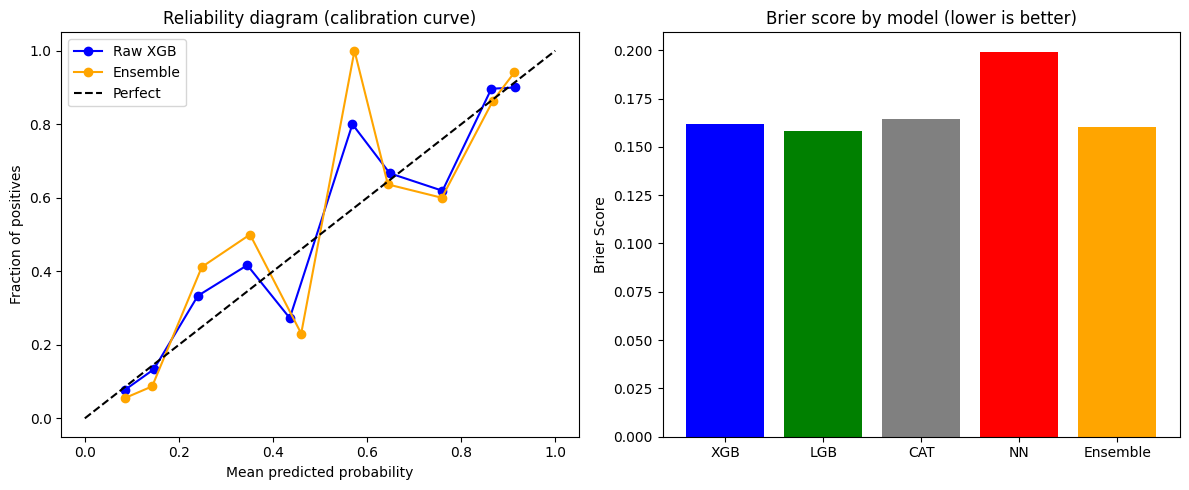

In [54]:
# reliability diagram
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for proba, label, color in [(xgb_test_proba, 'Raw XGB', 'blue'), (ensemble_proba, 'Ensemble', 'orange')]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax[0].plot(mean_pred, frac_pos, marker='o', label=label, color=color)
ax[0].plot([0, 1], [0, 1], 'k--', label='Perfect')
ax[0].set_title('Reliability diagram (calibration curve)')
ax[0].set_xlabel('Mean predicted probability')
ax[0].set_ylabel('Fraction of positives')
ax[0].legend()

# model comparison bar chart
model_names = ['XGB', 'LGB', 'CAT', 'NN', 'Ensemble']
brier_scores = [
    brier_score_loss(y_test, xgb_test_proba),
    brier_score_loss(y_test, lgb_test_proba),
    brier_score_loss(y_test, cat_test_proba),
    brier_score_loss(y_test, nn_test_proba),
    brier_score_loss(y_test, ensemble_proba),
]
ax[1].bar(model_names, brier_scores, color=['blue','green','gray','red','orange'])
ax[1].set_title('Brier score by model (lower is better)')
ax[1].set_ylabel('Brier Score')
plt.tight_layout()
plt.show()

In [55]:
#xgb list feature importances
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feat_cols
).sort_values(ascending=False)
dead_features = importance[importance < 0.005].index.tolist()
print(f"Dropping {len(dead_features)} near-zero importance features")
print(dead_features)

Dropping 6 near-zero importance features
['IsTenSeven', 'IsElevenSix', 'IsFiveTwelve', 'Rank_ESPN_diff', 'Vulnerable_Top_2_Seed_diff', 'IsThirteenFour']


<Figure size 1200x800 with 0 Axes>

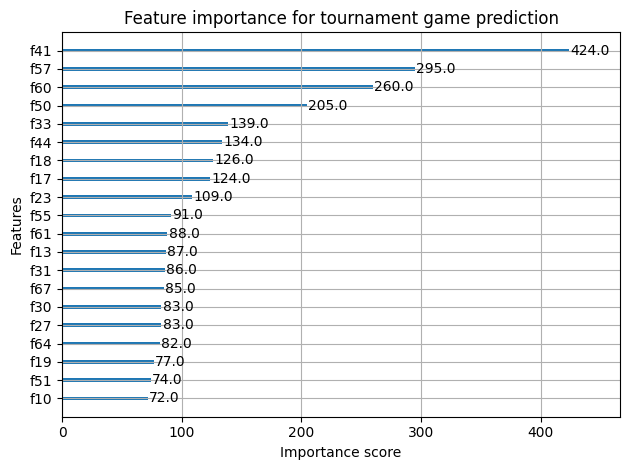

In [56]:
#xgb feat importance
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_model, max_num_features=20, importance_type='weight', title='Feature importance (XGBoost)')
plt.title('Feature importance for tournament game prediction')
plt.tight_layout()
plt.show()

# Simulation

In [57]:
sim_model = EnsembleSimModel(
    models=[xgb_model, lgb_model, cat_model],
    weights=optimal_weights.tolist(),
)
print(f"\nFinal ensemble weights: {optimal_weights.tolist()}")


Final ensemble weights: [0.5349050917748521, 0.21435982829881056, 0.25073507992633737]


In [58]:
team_dict = dict(zip(teams['TeamID'], teams['TeamName']))

In [59]:
team_features['ESPN_Name'].unique()

array(['Air Force', 'Akron', 'Alabama', 'Alabama A&M', nan, 'Arizona',
       'Arkansas', 'Army', 'Auburn', 'Austin Peay', 'Baylor', 'Belmont',
       'Bethune-Cookman', 'Binghamton', 'Boston College', 'Bowling Green',
       'Bradley', 'Brown', 'Bucknell', 'Buffalo', 'Butler', 'BYU',
       'Cal Poly', 'California', 'Campbell', 'Canisius', 'Charlotte',
       'Chattanooga', 'Cincinnati', 'Clemson', 'Colgate', 'Colorado',
       'Columbia', 'Cornell', 'Creighton', 'Dartmouth', 'Davidson',
       'Dayton', 'Delaware', 'Denver', 'DePaul', 'Drake', 'Drexel',
       'Duke', 'Duquesne', 'East Carolina', 'Elon', 'Evansville',
       'Fairfield', 'Florida', 'Florida A&M', 'Fordham', 'Furman',
       'George Mason', 'Georgetown', 'Georgia', 'Georgia Tech', 'Gonzaga',
       'Grambling', 'Hampton', 'Hartford', 'Harvard', 'Hawaii',
       'High Point', 'Hofstra', 'Holy Cross', 'Houston', 'Howard',
       'Idaho', 'Illinois', 'Indiana', 'Iona', 'Iowa', 'Jacksonville',
       'James Madison', 'Kan

In [60]:
def extract_sim_features(team_a_name, team_b_name, team_a_seed, team_b_seed, round_num, season, team_features, scaler, feat_cols):
    a_feats = team_features[(team_features['Season'] == season) & (team_features['TeamID'].map(id_to_name) == team_a_name)]
    b_feats = team_features[(team_features['Season'] == season) & (team_features['TeamID'].map(id_to_name) == team_b_name)]

    if len(a_feats) == 0 or len(b_feats) == 0:
        raise ValueError(f"Could not find features for team {team_a_name} or {team_b_name} in season {season}")

    seed_pair = tuple(sorted([team_a_seed, team_b_seed]))
    fav_feats = a_feats if team_a_seed <= team_b_seed else b_feats

    features = {
        'Round':               round_num,
        'SeedDiff':            team_b_seed - team_a_seed,
        'Seed_A':              team_a_seed,
        'Seed_B':              team_b_seed,
        'SeedProduct':         team_a_seed * team_b_seed,
        'HighSeedGame':        int(min(team_a_seed, team_b_seed) >= 4),
        'IsFiveTwelve':        int(seed_pair == (5, 12)),
        'IsElevenSix':         int(seed_pair == (6, 11)),
        'IsTenSeven':          int(seed_pair == (7, 10)),
        'IsThirteenFour':      int(seed_pair == (4, 13)),
        'FavoriteVulnerability': float(fav_feats['VulnerabilityScore'].values[0])
                                  if 'VulnerabilityScore' in fav_feats.columns else 0.0,
    }

    for col in FEATURE_COLS:
        diff_col = f'{col}_diff'
        if diff_col in feat_cols:
            a_val = float(a_feats[col].values[0]) if col in a_feats.columns else 0.0
            b_val = float(b_feats[col].values[0]) if col in b_feats.columns else 0.0
            features[diff_col] = a_val - b_val

    feat_df = pd.DataFrame([features])[feat_cols]
    feat_scaled = scaler.transform(feat_df)
    return feat_df, feat_scaled

## Single Game Sim

In [61]:
def simulate_game(team_a_name, team_b_name, team_a_seed, team_b_seed, round_num, season,
                  team_features, scaler, feat_cols, model, n_sims=10000):
    features_df, features_scaled = extract_sim_features(
        team_a_name, team_b_name, team_a_seed, team_b_seed, round_num, season, team_features, scaler, feat_cols
    )
    team_a_win_prob = model.predict_proba(features_scaled)[0, 1]
    team_b_win_prob = 1 - team_a_win_prob

    sim_results = np.random.binomial(n=1, p=team_a_win_prob, size=n_sims)
    team_a_sim_pct = np.sum(sim_results) / n_sims
    team_b_sim_pct = 1 - team_a_sim_pct

    result = {
        'team_a': {
            'name': team_a_name,
            'seed': team_a_seed,
            'win_probability': round(float(team_a_win_prob), 5),
            'simulated_win_pct': round(float(team_a_sim_pct), 5)
        },
        'team_b': {
            'name': team_b_name,
            'seed': team_b_seed,
            'win_probability': round(float(team_b_win_prob), 5),
            'simulated_win_pct': round(float(team_b_sim_pct), 5)
        },
        'predicted_winner': team_a_name if team_a_win_prob > 0.5 else team_b_name,
        'round': round_num,
    }
    return result

In [62]:
test_team_a_name = "Duke"
test_team_b_name = "Arizona"
test_team_a_seed = 1
test_team_b_seed = 1
test_round = 6

In [63]:
test_result = simulate_game(
    test_team_a_name, test_team_b_name, test_team_a_seed, test_team_b_seed,
    test_round, 2026, team_features, scaler, feat_cols, sim_model
)

In [64]:
print(f"\n----- {test_result['team_a']['name']} vs {test_result['team_b']['name']} -----")
print(f"Round: {test_round}")
print(f"{test_result['team_a']['name']} (Seed {test_result['team_a']['seed']}): {test_result['team_a']['win_probability']:.1%} win probability, won in {test_result['team_a']['simulated_win_pct']:.2%} of simulations")
print(f"{test_result['team_b']['name']} (Seed {test_result['team_b']['seed']}): {test_result['team_b']['win_probability']:.1%} win probability, won in {test_result['team_b']['simulated_win_pct']:.2%} of simulations")
print(f"Predicted Winner: {test_result['predicted_winner']}")


----- Duke vs Arizona -----
Round: 6
Duke (Seed 1): 75.7% win probability, won in 75.95% of simulations
Arizona (Seed 1): 24.3% win probability, won in 24.05% of simulations
Predicted Winner: Duke


## Running Sim on 2026 Bracket

In [65]:
bracket = pd.read_csv('bracket2026.csv')
bracket

,teamId,conference,seed
0,1181,W,01
1,1163,W,02
2,1277,W,03
3,1242,W,04
4,1385,W,05
...,...,...,...
63,1220,Z,13
64,1460,Z,14
65,1398,Z,15
66,1420,Z,16a


In [66]:
bracket['name'] = bracket['teamId'].map(team_dict)
bracket['espn_name'] = bracket['name'].str.strip()
bracket

,teamId,conference,seed,name,espn_name
0,1181,W,01,Duke,Duke
1,1163,W,02,Connecticut,Connecticut
2,1277,W,03,Michigan St,Michigan St
3,1242,W,04,Kansas,Kansas
4,1385,W,05,St John's,St John's
...,...,...,...,...,...
63,1220,Z,13,Hofstra,Hofstra
64,1460,Z,14,Wright St,Wright St
65,1398,Z,15,Tennessee St,Tennessee St
66,1420,Z,16a,UMBC,UMBC


In [67]:
play_in_teams = bracket[bracket['seed'].str.contains('a') | bracket['seed'].str.contains('b')]
play_in_teams

,teamId,conference,seed,name,espn_name
31,1341,X,16a,Prairie View,Prairie View
32,1250,X,16b,Lehigh,Lehigh
43,1400,Y,11a,Texas,Texas
44,1301,Y,11b,NC State,NC State
60,1374,Z,11a,SMU,SMU
61,1275,Z,11b,Miami OH,Miami OH
66,1420,Z,16a,UMBC,UMBC
67,1224,Z,16b,Howard,Howard


In [68]:
play_in_results = []
for i in range(len(play_in_teams) // 2):
    team_a_name = play_in_teams.iloc[i * 2]['espn_name']
    team_b_name = play_in_teams.iloc[i * 2 + 1]['espn_name']
    team_a_seed = int(play_in_teams.iloc[i * 2]['seed'][:-1])
    team_b_seed = int(play_in_teams.iloc[i * 2 + 1]['seed'][:-1])
    result = simulate_game(team_a_name, team_b_name, team_a_seed, team_b_seed, 0, 2026, team_features, scaler, feat_cols, sim_model)
    play_in_results.append(result)

In [69]:
play_in_winners_updated = []
for result in play_in_results:
    play_in_winners_updated.append(result['predicted_winner'])
play_in_winners_updated

['Prairie View', 'NC State', 'SMU', 'UMBC']

In [70]:
for team in play_in_teams['espn_name']:
    if team in play_in_winners_updated:
        bracket.loc[bracket['espn_name'] == team, 'seed'] = bracket.loc[bracket['name'] == team, 'seed'].astype(str).str[:2]
    else:
        bracket.drop(bracket[bracket['name'] == team].index, inplace=True)
bracket.reset_index(drop=True, inplace=True)
bracket.index += 1
bracket.head(20)

,teamId,conference,seed,name,espn_name
1,1181,W,01,Duke,Duke
2,1163,W,02,Connecticut,Connecticut
3,1277,W,03,Michigan St,Michigan St
4,1242,W,04,Kansas,Kansas
5,1385,W,05,St John's,St John's
6,1257,W,06,Louisville,Louisville
7,1417,W,07,UCLA,UCLA
8,1326,W,08,Ohio St,Ohio St
9,1395,W,09,TCU,TCU
10,1416,W,10,UCF,UCF


In [71]:
first_round_matchups = []
num_teams = len(bracket)
matchups_per_region = num_teams // 4

for region_start in range(0, num_teams, matchups_per_region):
    for i in range(matchups_per_region // 2):
        team_a_index = region_start + i
        team_b_index = region_start + (matchups_per_region - 1 - i)        
        team_a_name = bracket.iloc[team_a_index]['espn_name']
        team_b_name = bracket.iloc[team_b_index]['espn_name']
        team_a_seed = int(bracket.iloc[team_a_index]['seed'])
        team_b_seed = int(bracket.iloc[team_b_index]['seed'])

        matchup = {
            "team_a": team_a_name,
            "team_b": team_b_name,
            "team_a_seed": team_a_seed,
            "team_b_seed": team_b_seed,
            "round": 1
        }
        first_round_matchups.append(matchup)
first_round_matchups

[{'team_a': 'Duke',
  'team_b': 'Siena',
  'team_a_seed': 1,
  'team_b_seed': 16,
  'round': 1},
 {'team_a': 'Connecticut',
  'team_b': 'Furman',
  'team_a_seed': 2,
  'team_b_seed': 15,
  'round': 1},
 {'team_a': 'Michigan St',
  'team_b': 'N Dakota St',
  'team_a_seed': 3,
  'team_b_seed': 14,
  'round': 1},
 {'team_a': 'Kansas',
  'team_b': 'Cal Baptist',
  'team_a_seed': 4,
  'team_b_seed': 13,
  'round': 1},
 {'team_a': "St John's",
  'team_b': 'Northern Iowa',
  'team_a_seed': 5,
  'team_b_seed': 12,
  'round': 1},
 {'team_a': 'Louisville',
  'team_b': 'South Florida',
  'team_a_seed': 6,
  'team_b_seed': 11,
  'round': 1},
 {'team_a': 'UCLA',
  'team_b': 'UCF',
  'team_a_seed': 7,
  'team_b_seed': 10,
  'round': 1},
 {'team_a': 'Ohio St',
  'team_b': 'TCU',
  'team_a_seed': 8,
  'team_b_seed': 9,
  'round': 1},
 {'team_a': 'Florida',
  'team_b': 'Prairie View',
  'team_a_seed': 1,
  'team_b_seed': 16,
  'round': 1},
 {'team_a': 'Houston',
  'team_b': 'Idaho',
  'team_a_seed': 2,

In [72]:
def sort_matchups(matchups):
    correct_order = [1, 16, 8, 9, 5, 12, 4, 13, 6, 11, 3, 14, 7, 10, 2, 15]
    return sorted(matchups, key=lambda matchup: (correct_order.index(matchup['team_a_seed']), correct_order.index(matchup['team_b_seed'])))

In [73]:
div1_matchups = sort_matchups(first_round_matchups[0:8])
div2_matchups = sort_matchups(first_round_matchups[8:16])
div3_matchups = sort_matchups(first_round_matchups[16:24])
div4_matchups = sort_matchups(first_round_matchups[24:32])
first_round_matchups_sorted = div1_matchups + div2_matchups + div3_matchups + div4_matchups
first_round_matchups_sorted

[{'team_a': 'Duke',
  'team_b': 'Siena',
  'team_a_seed': 1,
  'team_b_seed': 16,
  'round': 1},
 {'team_a': 'Ohio St',
  'team_b': 'TCU',
  'team_a_seed': 8,
  'team_b_seed': 9,
  'round': 1},
 {'team_a': "St John's",
  'team_b': 'Northern Iowa',
  'team_a_seed': 5,
  'team_b_seed': 12,
  'round': 1},
 {'team_a': 'Kansas',
  'team_b': 'Cal Baptist',
  'team_a_seed': 4,
  'team_b_seed': 13,
  'round': 1},
 {'team_a': 'Louisville',
  'team_b': 'South Florida',
  'team_a_seed': 6,
  'team_b_seed': 11,
  'round': 1},
 {'team_a': 'Michigan St',
  'team_b': 'N Dakota St',
  'team_a_seed': 3,
  'team_b_seed': 14,
  'round': 1},
 {'team_a': 'UCLA',
  'team_b': 'UCF',
  'team_a_seed': 7,
  'team_b_seed': 10,
  'round': 1},
 {'team_a': 'Connecticut',
  'team_b': 'Furman',
  'team_a_seed': 2,
  'team_b_seed': 15,
  'round': 1},
 {'team_a': 'Florida',
  'team_b': 'Prairie View',
  'team_a_seed': 1,
  'team_b_seed': 16,
  'round': 1},
 {'team_a': 'Clemson',
  'team_b': 'Iowa',
  'team_a_seed': 8,


In [74]:
def simulate_bracket(bracket_matchups, season, team_features, scaler, feat_cols, model):
    results = {'rounds': {}}
    winners = []
    current_matchups = bracket_matchups
    current_round = 1
    champ_match = None

    while len(current_matchups) > 0:
        round_results = []
        next_round_matchups = []
        temp_winner = None

        for i, matchup in enumerate(current_matchups):
            result = simulate_game(
                matchup['team_a'], matchup['team_b'],
                matchup['team_a_seed'], matchup['team_b_seed'],
                current_round, season, team_features, scaler, feat_cols, model
            )
            round_results.append(result)

            winner = result['predicted_winner']
            winner_seed = matchup['team_a_seed'] if winner == matchup['team_a'] else matchup['team_b_seed']
            winners.append({'winner': winner, 'matchup': matchup})

            if i % 2 == 0:
                temp_winner = {'team': winner, 'seed': winner_seed}
            else:
                next_round_matchups.append({
                    'team_a': temp_winner['team'],
                    'team_b': winner,
                    'team_a_seed': temp_winner['seed'],
                    'team_b_seed': winner_seed,
                    'round': current_round + 1
                })

        results['rounds'][f'Round_{current_round}'] = round_results
        if len(current_matchups) == 1:
            champ_match = current_matchups[0]
        current_round += 1
        current_matchups = next_round_matchups

    final_round = max(int(k.split('_')[1]) for k in results['rounds'].keys())
    champion = results['rounds'][f'Round_{final_round}'][0]['predicted_winner']
    results['champion'] = champion
    winners.append({'winner': champion, 'matchup': champ_match})
    
    return results, winners

In [75]:
def simulate_bracket_probabilistic(bracket_matchups, season, team_features,
                                    scaler, feat_cols, model, n_bracket_sims=1000):
    round_labels = {1: 'R64', 2: 'R32', 3: 'S16', 4: 'E8', 5: 'F4', 6: 'Champion'}
    all_teams = set(
        [m['team_a'] for m in bracket_matchups] +
        [m['team_b'] for m in bracket_matchups]
    )
    # initialize counts for all teams
    round_win_counts = {team: {r: 0 for r in range(1, 7)} for team in all_teams}

    for sim in range(n_bracket_sims):
        current_matchups = [m.copy() for m in bracket_matchups]
        current_round = 1

        while current_matchups:
            next_winners = []

            for matchup in current_matchups:
                try:
                    result = simulate_game(
                        matchup['team_a'], matchup['team_b'],
                        matchup['team_a_seed'], matchup['team_b_seed'],
                        current_round, season, team_features,
                        scaler, feat_cols, model, n_sims=1
                    )
                    prob_a = result['team_a']['win_probability']
                    won_a  = np.random.random() < prob_a
                except Exception:
                    won_a = True  # fallback

                if won_a:
                    winner      = matchup['team_a']
                    winner_seed = matchup['team_a_seed']
                else:
                    winner      = matchup['team_b']
                    winner_seed = matchup['team_b_seed']

                # record this team advancing to this round
                if winner in round_win_counts:
                    round_win_counts[winner][current_round] += 1

                next_winners.append({'name': winner, 'seed': winner_seed})

            # pair winners for next round
            next_matchups = []
            for i in range(0, len(next_winners) - 1, 2):
                a, b = next_winners[i], next_winners[i + 1]
                next_matchups.append({
                    'team_a':      a['name'],
                    'team_a_seed': a['seed'],
                    'team_b':      b['name'],
                    'team_b_seed': b['seed'],
                })
            current_matchups = next_matchups
            current_round += 1

        if (sim + 1) % 200 == 0:
            print(f"  {sim + 1}/{n_bracket_sims} sims done...")

    # build summary
    team_seed_map = {}
    for m in bracket_matchups:
        team_seed_map[m['team_a']] = m['team_a_seed']
        team_seed_map[m['team_b']] = m['team_b_seed']

    rows = []
    for team in all_teams:
        counts = round_win_counts[team]
        rows.append({
            'team':     team,
            'seed':     team_seed_map.get(team, 99),
            'R64':      counts[1] / n_bracket_sims,
            'R32':      counts[2] / n_bracket_sims,
            'Sweet16':  counts[3] / n_bracket_sims,
            'Elite8':   counts[4] / n_bracket_sims,
            'Final4':   counts[5] / n_bracket_sims,
            'Champion': counts[6] / n_bracket_sims,
        })

    df = pd.DataFrame(rows).sort_values('Champion', ascending=False).reset_index(drop=True)
    return df

In [76]:
print("Running 1000 bracket simulations...")
bracket_sim = simulate_bracket_probabilistic(
    first_round_matchups_sorted, 2026, team_features,
    scaler, feat_cols, sim_model, n_bracket_sims=1000
)

Running 1000 bracket simulations...
  200/1000 sims done...
  400/1000 sims done...
  600/1000 sims done...
  800/1000 sims done...
  1000/1000 sims done...



=== Championship Probabilities (Top 20) ===


,team,seed,Sweet16,Elite8,Final4,Champion
0,Duke,1,76.5%,70.8%,52.2%,41.0%
1,Arizona,1,72.0%,64.6%,42.5%,21.7%
2,Michigan,1,65.1%,58.8%,35.9%,13.9%
3,Houston,2,62.7%,42.8%,21.2%,10.9%
4,Florida,1,74.6%,35.8%,14.7%,5.8%
5,Illinois,3,33.9%,18.1%,8.1%,3.3%
6,Purdue,2,52.3%,15.2%,5.7%,1.3%
7,Gonzaga,3,30.8%,9.1%,4.3%,0.7%
8,Louisville,6,68.2%,13.3%,1.9%,0.3%
9,Alabama,4,19.8%,8.4%,1.3%,0.2%



=== Model's Top Upset Candidates ===


,team,seed,Sweet16,Elite8,Final4,Champion
18,Villanova,8,5.0%,1.1%,0.0%,0.0%
51,Santa Clara,10,5.6%,1.0%,0.0%,0.0%
8,Louisville,6,68.2%,13.3%,1.9%,0.3%
12,BYU,6,11.6%,2.8%,1.7%,0.2%
14,UCLA,7,24.9%,3.6%,0.3%,0.1%
15,Tennessee,6,27.7%,8.3%,1.0%,0.1%
62,Kentucky,7,8.4%,1.1%,0.2%,0.0%
16,Wisconsin,5,6.7%,1.9%,0.4%,0.0%
29,Texas Tech,5,10.5%,4.1%,0.5%,0.0%
42,Vanderbilt,5,17.0%,2.6%,0.5%,0.0%



=== First Round Upset Odds (Seeds 12-16) ===
Chance of advancing past Round of 64



,team,seed,R32,Sweet16,Elite8
0,Northern Iowa,12,16.2%,1.7%,0.2%
1,Akron,12,1.8%,0.2%,0.0%
2,McNeese St,12,1.3%,0.1%,0.0%
3,High Point,12,1.1%,0.1%,0.0%
4,Hofstra,13,2.1%,0.2%,0.1%
5,Troy,13,1.6%,0.3%,0.0%
6,Hawaii,13,1.0%,0.0%,0.0%
7,Cal Baptist,13,0.5%,0.1%,0.0%
8,N Dakota St,14,7.1%,1.3%,0.1%
9,Kennesaw,14,1.0%,0.1%,0.0%


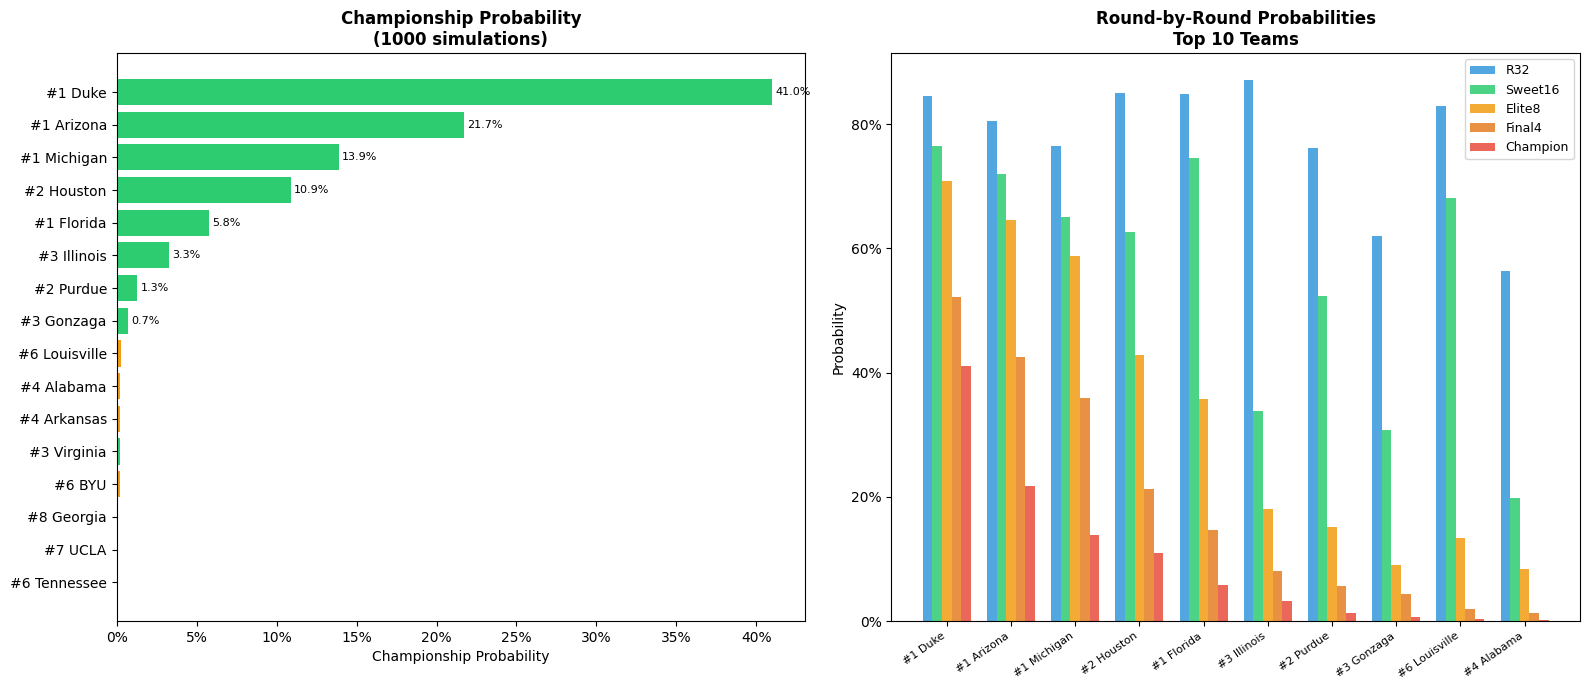


Most likely champion:  #1 Duke (41.0%)
Most likely Final Four:
  #1 Duke — 52.2% F4 | 41.0% champ
  #1 Arizona — 42.5% F4 | 21.7% champ
  #1 Michigan — 35.9% F4 | 13.9% champ
  #2 Houston — 21.2% F4 | 10.9% champ

Top upset pick:  #8 Villanova (5.0% Sweet 16, 0.0% champ)


In [77]:
# ── Results table ──────────────────────────────────────────────────────────────
print("\n=== Championship Probabilities (Top 20) ===")
display(
    bracket_sim[['team', 'seed', 'Sweet16', 'Elite8', 'Final4', 'Champion']]
    .head(20)
    .reset_index(drop=True)
    .style.format({
        'seed':     '{:.0f}',
        'Sweet16':  '{:.1%}',
        'Elite8':   '{:.1%}',
        'Final4':   '{:.1%}',
        'Champion': '{:.1%}',
    })
    .background_gradient(subset=['Champion'], cmap='YlOrRd')
)

# ── Upset spotter ──────────────────────────────────────────────────────────────
seed_baselines = {
    1: 0.28, 2: 0.12, 3: 0.07, 4: 0.05, 5: 0.03,
    6: 0.02, 7: 0.02, 8: 0.01, 9: 0.01, 10: 0.01,
    11: 0.01, 12: 0.005, 13: 0.002, 14: 0.001, 15: 0.0, 16: 0.0
}
bracket_sim['baseline']    = bracket_sim['seed'].map(seed_baselines).fillna(0.01)
bracket_sim['upset_score'] = bracket_sim['Champion'] - bracket_sim['baseline']

upset_picks = bracket_sim[
    (bracket_sim['seed'] >= 5) &
    (bracket_sim['Sweet16'] >= 0.05)   # at least 5% sweet 16 — more lenient filter
].sort_values('upset_score', ascending=False)

print("\n=== Model's Top Upset Candidates ===")
if len(upset_picks) > 0:
    display(
        upset_picks[['team', 'seed', 'Sweet16', 'Elite8', 'Final4', 'Champion']]
        .head(10)
        .style.format({
            'seed':     '{:.0f}',
            'Sweet16':  '{:.1%}',
            'Elite8':   '{:.1%}',
            'Final4':   '{:.1%}',
            'Champion': '{:.1%}',
        })
    )
else:
    print("No strong upset candidates found — model is very chalk this year.")

# ── First round upset odds for seeds 12-16 ────────────────────────────────────
print("\n=== First Round Upset Odds (Seeds 12-16) ===")
print("Chance of advancing past Round of 64\n")

longshots = bracket_sim[
    bracket_sim['seed'].between(12, 16)
].sort_values(['seed', 'R32'], ascending=[True, False])[
    ['team', 'seed', 'R32', 'Sweet16', 'Elite8']
].reset_index(drop=True)

if len(longshots) > 0:
    display(
        longshots.style.format({
            'seed':    '{:.0f}',
            'R32':     '{:.1%}',
            'Sweet16': '{:.1%}',
            'Elite8':  '{:.1%}',
        })
        .background_gradient(subset=['R32'], cmap='YlOrRd')
        .set_caption('Seeds 12-16: First Round Survival Odds')
    )

else:
    print("No seeds 12-16 found in bracket data.")

# ── Visualizations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: championship probability bar chart
top16 = bracket_sim.head(16).copy()
colors = [f'#{max(0, int(255*(1-i/15))):02x}{min(255, int(180+75*(i/15))):02x}00'
          for i in range(len(top16))]
bars = axes[0].barh(
    [f"#{int(r.seed)} {r.team}" for _, r in top16.iterrows()],
    top16['Champion'],
    color=['#2ecc71' if s <= 3 else '#f39c12' if s <= 6 else '#e74c3c'
           for s in top16['seed']]
)
axes[0].set_xlabel('Championship Probability')
axes[0].set_title('Championship Probability\n(1000 simulations)', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].invert_yaxis()
for bar, val in zip(bars, top16['Champion']):
    if val > 0.005:
        axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{val:.1%}', va='center', fontsize=8)

# Right: round-by-round stacked view for top 10
top10 = bracket_sim.head(10)
rounds = ['R32', 'Sweet16', 'Elite8', 'Final4', 'Champion']
round_colors = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
x = np.arange(len(top10))
width = 0.15
for i, (r, c) in enumerate(zip(rounds, round_colors)):
    axes[1].bar(x + i * width, top10[r], width, label=r, color=c, alpha=0.85)
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(
    [f"#{int(r.seed)} {r.team}" for _, r in top10.iterrows()],
    rotation=35, ha='right', fontsize=8
)
axes[1].set_ylabel('Probability')
axes[1].set_title('Round-by-Round Probabilities\nTop 10 Teams', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('bracket_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary printout ───────────────────────────────────────────────────────────
champ = bracket_sim.iloc[0]
print(f"\nMost likely champion:  #{int(champ.seed)} {champ.team} ({champ.Champion:.1%})")
print(f"Most likely Final Four:")
for _, r in bracket_sim.head(4).iterrows():
    print(f"  #{int(r.seed)} {r.team} — {r.Final4:.1%} F4 | {r.Champion:.1%} champ")

if len(upset_picks) > 0:
    u = upset_picks.iloc[0]
    print(f"\nTop upset pick:  #{int(u.seed)} {u.team} "
          f"({u.Sweet16:.1%} Sweet 16, {u.Champion:.1%} champ)")

In [78]:
results, winners = simulate_bracket(first_round_matchups_sorted, 2026, team_features, scaler, feat_cols, sim_model)

In [79]:
results

{'rounds': {'Round_1': [{'team_a': {'name': 'Duke',
     'seed': 1,
     'win_probability': 0.88957,
     'simulated_win_pct': 0.89},
    'team_b': {'name': 'Siena',
     'seed': 16,
     'win_probability': 0.11043,
     'simulated_win_pct': 0.11},
    'predicted_winner': 'Duke',
    'round': 1},
   {'team_a': {'name': 'Ohio St',
     'seed': 8,
     'win_probability': 0.07065,
     'simulated_win_pct': 0.0725},
    'team_b': {'name': 'TCU',
     'seed': 9,
     'win_probability': 0.92935,
     'simulated_win_pct': 0.9275},
    'predicted_winner': 'TCU',
    'round': 1},
   {'team_a': {'name': "St John's",
     'seed': 5,
     'win_probability': 0.11175,
     'simulated_win_pct': 0.1106},
    'team_b': {'name': 'Northern Iowa',
     'seed': 12,
     'win_probability': 0.88825,
     'simulated_win_pct': 0.8894},
    'predicted_winner': 'Northern Iowa',
    'round': 1},
   {'team_a': {'name': 'Kansas',
     'seed': 4,
     'win_probability': 0.92703,
     'simulated_win_pct': 0.9301},
  

In [80]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.float32):
            return float(obj)
        return super().default(obj)

with open('results.json', 'w') as f:
    json.dump(results, f, cls=NumpyEncoder)

In [81]:
winners

[{'winner': 'Duke',
  'matchup': {'team_a': 'Duke',
   'team_b': 'Siena',
   'team_a_seed': 1,
   'team_b_seed': 16,
   'round': 1}},
 {'winner': 'TCU',
  'matchup': {'team_a': 'Ohio St',
   'team_b': 'TCU',
   'team_a_seed': 8,
   'team_b_seed': 9,
   'round': 1}},
 {'winner': 'Northern Iowa',
  'matchup': {'team_a': "St John's",
   'team_b': 'Northern Iowa',
   'team_a_seed': 5,
   'team_b_seed': 12,
   'round': 1}},
 {'winner': 'Kansas',
  'matchup': {'team_a': 'Kansas',
   'team_b': 'Cal Baptist',
   'team_a_seed': 4,
   'team_b_seed': 13,
   'round': 1}},
 {'winner': 'Louisville',
  'matchup': {'team_a': 'Louisville',
   'team_b': 'South Florida',
   'team_a_seed': 6,
   'team_b_seed': 11,
   'round': 1}},
 {'winner': 'N Dakota St',
  'matchup': {'team_a': 'Michigan St',
   'team_b': 'N Dakota St',
   'team_a_seed': 3,
   'team_b_seed': 14,
   'round': 1}},
 {'winner': 'UCLA',
  'matchup': {'team_a': 'UCLA',
   'team_b': 'UCF',
   'team_a_seed': 7,
   'team_b_seed': 10,
   'round'

In [82]:
winners_df = pd.DataFrame(winners)
winners_df

,winner,matchup
0,Duke,"{'team_a': 'Duke', 'team_b': 'Siena', 'team_a_..."
1,TCU,"{'team_a': 'Ohio St', 'team_b': 'TCU', 'team_a..."
2,Northern Iowa,"{'team_a': 'St John's', 'team_b': 'Northern Io..."
3,Kansas,"{'team_a': 'Kansas', 'team_b': 'Cal Baptist', ..."
4,Louisville,"{'team_a': 'Louisville', 'team_b': 'South Flor..."
...,...,...
59,Michigan,"{'team_a': 'Michigan', 'team_b': 'Virginia', '..."
60,Duke,"{'team_a': 'Duke', 'team_b': 'Houston', 'team_..."
61,Michigan,"{'team_a': 'Arizona', 'team_b': 'Michigan', 't..."
62,Duke,"{'team_a': 'Duke', 'team_b': 'Michigan', 'team..."


In [94]:
winners_df.to_csv('winners.csv', index=False)

## Running Second Chance Bracket for 2026

In [83]:
bracket2 = pd.read_csv('bracket2nd2026.csv')
bracket2

,teamId,conference,seed
0,1181,W,1
1,1385,W,5
2,1277,W,3
3,1163,W,2
4,1234,X,9
5,1304,X,4
6,1228,X,3
7,1222,X,2
8,1112,Y,1
9,1116,Y,4


In [95]:
bracket2['name'] = bracket2['teamId'].map(team_dict)
bracket2['espn_name'] = bracket2['name'].str.strip()
bracket2

,teamId,conference,seed,name,espn_name
0,1181,W,1,Duke,Duke
1,1385,W,5,St John's,St John's
2,1277,W,3,Michigan St,Michigan St
3,1163,W,2,Connecticut,Connecticut
4,1234,X,9,Iowa,Iowa
5,1304,X,4,Nebraska,Nebraska
6,1228,X,3,Illinois,Illinois
7,1222,X,2,Houston,Houston
8,1112,Y,1,Arizona,Arizona
9,1116,Y,4,Arkansas,Arkansas


In [85]:
sweet_16_matchups = []
num_teams = len(bracket2)
matchups_skip = 2

for i in range(0, num_teams, matchups_skip):
    team_a_index = i
    team_b_index = i + 1
    team_a_name = bracket2.iloc[team_a_index]['espn_name']
    team_b_name = bracket2.iloc[team_b_index]['espn_name']
    team_a_seed = int(bracket2.iloc[team_a_index]['seed'])
    team_b_seed = int(bracket2.iloc[team_b_index]['seed'])

    matchup = {
        "team_a": team_a_name,
        "team_b": team_b_name,
        "team_a_seed": team_a_seed,
        "team_b_seed": team_b_seed,
        "round": 3
    }
    sweet_16_matchups.append(matchup)
sweet_16_matchups

[{'team_a': 'Duke',
  'team_b': "St John's",
  'team_a_seed': 1,
  'team_b_seed': 5,
  'round': 3},
 {'team_a': 'Michigan St',
  'team_b': 'Connecticut',
  'team_a_seed': 3,
  'team_b_seed': 2,
  'round': 3},
 {'team_a': 'Iowa',
  'team_b': 'Nebraska',
  'team_a_seed': 9,
  'team_b_seed': 4,
  'round': 3},
 {'team_a': 'Illinois',
  'team_b': 'Houston',
  'team_a_seed': 3,
  'team_b_seed': 2,
  'round': 3},
 {'team_a': 'Arizona',
  'team_b': 'Arkansas',
  'team_a_seed': 1,
  'team_b_seed': 4,
  'round': 3},
 {'team_a': 'Texas',
  'team_b': 'Purdue',
  'team_a_seed': 11,
  'team_b_seed': 2,
  'round': 3},
 {'team_a': 'Michigan',
  'team_b': 'Alabama',
  'team_a_seed': 1,
  'team_b_seed': 4,
  'round': 3},
 {'team_a': 'Tennessee',
  'team_b': 'Iowa St',
  'team_a_seed': 6,
  'team_b_seed': 2,
  'round': 3}]

In [86]:
results2, winners2 = simulate_bracket(sweet_16_matchups, 2026, team_features, scaler, feat_cols, sim_model)

In [87]:
results2

{'rounds': {'Round_1': [{'team_a': {'name': 'Duke',
     'seed': 1,
     'win_probability': 0.93584,
     'simulated_win_pct': 0.9355},
    'team_b': {'name': "St John's",
     'seed': 5,
     'win_probability': 0.06416,
     'simulated_win_pct': 0.0645},
    'predicted_winner': 'Duke',
    'round': 1},
   {'team_a': {'name': 'Michigan St',
     'seed': 3,
     'win_probability': 0.43656,
     'simulated_win_pct': 0.4373},
    'team_b': {'name': 'Connecticut',
     'seed': 2,
     'win_probability': 0.56344,
     'simulated_win_pct': 0.5627},
    'predicted_winner': 'Connecticut',
    'round': 1},
   {'team_a': {'name': 'Iowa',
     'seed': 9,
     'win_probability': 0.38417,
     'simulated_win_pct': 0.3874},
    'team_b': {'name': 'Nebraska',
     'seed': 4,
     'win_probability': 0.61583,
     'simulated_win_pct': 0.6126},
    'predicted_winner': 'Nebraska',
    'round': 1},
   {'team_a': {'name': 'Illinois',
     'seed': 3,
     'win_probability': 0.29288,
     'simulated_win_pct'

In [88]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.float32):
            return float(obj)
        return super().default(obj)

with open('results_secondchance.json', 'w') as f:
    json.dump(results2, f, cls=NumpyEncoder)

In [89]:
winners2

[{'winner': 'Duke',
  'matchup': {'team_a': 'Duke',
   'team_b': "St John's",
   'team_a_seed': 1,
   'team_b_seed': 5,
   'round': 3}},
 {'winner': 'Connecticut',
  'matchup': {'team_a': 'Michigan St',
   'team_b': 'Connecticut',
   'team_a_seed': 3,
   'team_b_seed': 2,
   'round': 3}},
 {'winner': 'Nebraska',
  'matchup': {'team_a': 'Iowa',
   'team_b': 'Nebraska',
   'team_a_seed': 9,
   'team_b_seed': 4,
   'round': 3}},
 {'winner': 'Houston',
  'matchup': {'team_a': 'Illinois',
   'team_b': 'Houston',
   'team_a_seed': 3,
   'team_b_seed': 2,
   'round': 3}},
 {'winner': 'Arizona',
  'matchup': {'team_a': 'Arizona',
   'team_b': 'Arkansas',
   'team_a_seed': 1,
   'team_b_seed': 4,
   'round': 3}},
 {'winner': 'Purdue',
  'matchup': {'team_a': 'Texas',
   'team_b': 'Purdue',
   'team_a_seed': 11,
   'team_b_seed': 2,
   'round': 3}},
 {'winner': 'Michigan',
  'matchup': {'team_a': 'Michigan',
   'team_b': 'Alabama',
   'team_a_seed': 1,
   'team_b_seed': 4,
   'round': 3}},
 {'wi

In [96]:
winners_df2 = pd.DataFrame(winners2)
winners_df2

,winner,matchup
0,Duke,"{'team_a': 'Duke', 'team_b': 'St John's', 'tea..."
1,Connecticut,"{'team_a': 'Michigan St', 'team_b': 'Connectic..."
2,Nebraska,"{'team_a': 'Iowa', 'team_b': 'Nebraska', 'team..."
3,Houston,"{'team_a': 'Illinois', 'team_b': 'Houston', 't..."
4,Arizona,"{'team_a': 'Arizona', 'team_b': 'Arkansas', 't..."
5,Purdue,"{'team_a': 'Texas', 'team_b': 'Purdue', 'team_..."
6,Michigan,"{'team_a': 'Michigan', 'team_b': 'Alabama', 't..."
7,Tennessee,"{'team_a': 'Tennessee', 'team_b': 'Iowa St', '..."
8,Duke,"{'team_a': 'Duke', 'team_b': 'Connecticut', 't..."
9,Houston,"{'team_a': 'Nebraska', 'team_b': 'Houston', 't..."


In [97]:
winners_df2.to_csv('winners_secondchance.csv', index=False)

## Kaggle Competition Submission CSV

In [98]:
def generate_submission(model, team_features, scaler, feat_cols, seeds,
                         season=2026, output_path='submission.csv'):
    season_teams = team_features[team_features['Season'] == season][['ESPN_Name', 'TeamID']].drop_duplicates()

    matchup_pairs = list(combinations(range(len(season_teams)), 2))
    submission_data = []

    for i, j in matchup_pairs:
        row_a = season_teams.iloc[i]
        row_b = season_teams.iloc[j]

        name_a, id_a = row_a['ESPN_Name'], int(row_a['TeamID'])
        name_b, id_b = row_b['ESPN_Name'], int(row_b['TeamID'])

        if id_a > id_b:
            name_a, id_a, name_b, id_b = name_b, id_b, name_a, id_a

        matchup_id = f"{season}_{id_a}_{id_b}"

        def get_seed(name, s=season):
            row = team_features[(team_features['Season'] == s) & (team_features['ESPN_Name'] == name)]
            return int(row['SeedNum'].values[0]) if len(row) > 0 and pd.notna(row['SeedNum'].values[0]) else 16

        try:
            _, features_scaled = extract_sim_features(
                name_a, name_b, get_seed(name_a), get_seed(name_b),
                1, season, team_features, scaler, feat_cols
            )
            pred = model.predict_proba(features_scaled)[0, 1]
        except:
            pred = 0.5

        submission_data.append({'ID': matchup_id, 'Pred': round(float(pred), 6)})

    submission_df = pd.DataFrame(submission_data)
    submission_df.to_csv(output_path, index=False)
    print(f"Saved {len(submission_df)} predictions to {output_path}")
    return submission_df

In [99]:
# generate_submission(sim_model, team_features, scaler, feat_cols, seeds, 2026, output_path='submission.csv')